# Deep Learning for Natural Language Processing - Exercise 4
## Author: Margarita Orfanidi ID: 7115152400023

This assignment investigates the task of identifying ambiguity in politicians' answers during interviews, based on the SemEval 2026 Task 6 (CLARITY) dataset. The problem is framed as a three-class classification task, where each question–answer pair must be assigned one of the following labels: **Clear Reply**, **Ambivalent**, or **Clear Non-Reply**.

Τhis work builds a classifier for the task of response clarity classification using an agentic approach with
instruction-tuned language models.

**Please note :** 
All experiments below are commented out to keep the Kaggle submission process efficient. These cells can be uncommented and executed to reproduce the corresponding results. At the end, a graph with hardcoded results summarizes the final outcomes.

### Libraries

In [1]:
# Libraries 
!pip install -q -U "transformers @ git+https://github.com/huggingface/transformers.git"
!pip install pyspellchecker emoji
!pip install -q sentence-transformers
!pip install -q dspy-ai
!python -m spacy download en_core_web_sm
!pip install pyspellchecker
!pip install -q dspy-ai
import json
import re
import random
import pandas as pd
import dspy
import time
import warnings
warnings.filterwarnings("ignore")
from kaggle_secrets import UserSecretsClient
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, classification_report
import numpy as np
from sklearn.metrics import  confusion_matrix
from tokenizers import Tokenizer
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from spellchecker import SpellChecker
import emoji
import os
import gc
import sys
from sklearn.neighbors import NearestNeighbors

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
sys.path.append("/kaggle/input/datasets/leloulv/utils-nlp-ex4")
print("Paths added.")


from Utils_ex4 import *
from helper_functions import *
from preprocessing_functions import *
from utils_ex2 import *


#set_seed(seed=42)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)



  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 95.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 113.8 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0

### Load Dataset

In [2]:
# Load the dataset (train and test sets)
dataset = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

# Exploratory Data Analysis
As a first step, it is important to explore the dataset in depth in order to better understand the nature and characteristics of the problem we aim to address. Our task is a classification problem focused on response clarity. Specifically, the goal is to classify political responses into predefined categories that reflect the level of clarity or evasiveness present in an answer.

Before proceeding to the modeling stage, it is necessary to perform an initial inspection of the dataset. This exploratory step allows us to examine basic statistics, understand the distribution of the labels, and identify potential patterns that appear in the data. Through this process, we can confirm the structure of the dataset, recognize the most important variables, and develop a clearer understanding of the problem we are attempting to solve.

## Metadata Analysis

This step helps verify that both train and test sets share the same structure (i.e., they contain the same columns) and allows us to inspect important properties such as the presence of missing values, data types, and the overall size of the datasets (number of entries) before further processing.

In [3]:
display(df_train.info())
display(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3448 entries, 0 to 3447
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  3448 non-null   object
 1   date                   3448 non-null   object
 2   president              3448 non-null   object
 3   url                    3448 non-null   object
 4   question_order         3448 non-null   int64 
 5   interview_question     3448 non-null   object
 6   interview_answer       3448 non-null   object
 7   gpt3.5_summary         3448 non-null   object
 8   gpt3.5_prediction      3448 non-null   object
 9   question               3448 non-null   object
 10  annotator_id           3448 non-null   object
 11  annotator1             0 non-null      object
 12  annotator2             0 non-null      object
 13  annotator3             0 non-null      object
 14  inaudible              3448 non-null   bool  
 15  multiple_questions   

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  0 non-null      object
 1   date                   0 non-null      object
 2   president              0 non-null      object
 3   url                    308 non-null    object
 4   question_order         308 non-null    int64 
 5   interview_question     308 non-null    object
 6   interview_answer       308 non-null    object
 7   gpt3.5_summary         0 non-null      object
 8   gpt3.5_prediction      0 non-null      object
 9   question               308 non-null    object
 10  annotator_id           0 non-null      object
 11  annotator1             308 non-null    object
 12  annotator2             308 non-null    object
 13  annotator3             308 non-null    object
 14  inaudible              308 non-null    bool  
 15  multiple_questions     

None

### Sample display
We displayed random samples from the dataset in order to observe the structure and formatting of the textual data. This qualitative inspection helps identify potential patterns and understand how the text appears in practice, allowing us to draw conclusions about the preprocessing steps that may be required. For example, we observed several spelling inconsistencies and cases where punctuation marks are not properly separated from words due to missing spaces.

In [4]:
# Display random samples of the training set
display_samples(df_train,1)

Sample 2900


,Value
title,"The President's News Conference With President Lee Myung-bak of South Korea at Camp David, Maryland"
date,"April 19, 2008"
president,George W. Bush
url,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea-camp-david
question_order,2
interview_question,"Q. I have a question for President Lee. Korea and the United States have made many achievements through the summit meeting, especially North Korean nuclear issue and the strengthening of the alliance. As for North Korean nuclear issue, Mr. President Lee suggested setting up a permanent liaison office in both Seoul and Pyongyang. What are some of the follow-up effects, if you do have any follow-up actions? And do you have any thoughts of proposing a meeting with Chairman Kim at an earlier date?"
interview_answer,"The process is not something that we discussed between ourselves during the summit meeting. In fact, when I was staying in Washington, DC, I had an interview with one of the newspapers there, and it came up. Of course, it was not a sudden suggestion. I did have a meeting among my staff and related ministries, and I talked about this in detail before I came to the United States.We have a new administration in Korea, and we haven't yet to begun dialogue with the ns. Inter-Korean dialogue, there is a need for us to have dialogue all the time. Up until now, we had dialogues whenever the need arose, and then it would stop. However, dialogue should be based on genuine cooperation and sincerity. And so with this in mind, I thought that it would be helpful to set up a permanent liaison office in both Seoul and Pyongyang.As for the summit meeting between myself and Chairman Kim, I will agree to it when the need is real. And I already said publicly that I am willing to meet with him—not just once, but many times—but if the meeting will yield substantial and real results. I believe only when that is possible, I am ready to meet with him and have sincere dialogue, because that will help to bring about peace and stability of the peninsula.So basically, I do hold that thought, but I'm not suggesting that—to have a meeting with Chairman Kim anytime soon. If the need arises, again, I'm ready to meet with him. Steven Lee [Steven Lee Myers, New York Times]."
gpt3.5_summary,"The question consists of 2 parts:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue.\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date.\n\n<--Summary Answer-->\n\nThe response provides the following information regarding these points:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue:\n- President Lee suggests setting up a permanent liaison office in both Seoul and Pyongyang to facilitate dialogue and cooperation between North Korea and South Korea.\n- The suggestion was made during an interview with a newspaper in Washington, DC, and was not discussed during the summit meeting.\n- The intention behind the suggestion is to establish genuine cooperation and sincerity in inter-Korean dialogue.\n\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date:\n- President Lee is open to the idea of a meeting with Chairman Kim, but only when the need is real and there is a possibility of substantial and real results.\n- He believes that sincere dialogue with Chairman Kim can contribute to the peace and stability of the Korean peninsula.\n- While he holds the thought of meeting with Chairman Kim, he is not suggesting a meeting anytime soon, but is willing to meet if the need arises.\n\nOverall, President Lee emphasizes the importance of genuine cooperation, sincerity, and substantial results in both the setup of a liaison office and the possibility of a meeting with Chairman Kim."
gpt3.5_prediction,"Question 1: Follow-up effects of setting up a permanent liaison office in Se

The responses are labeled based on whether they address each sub-question. As a result, the same response may appear multiple times in the dataset, depending on the number of sub-questions associated with a given interview question.

This behavior is illustrated below by displaying the original question, the corresponding sub-questions, the interview response, and the assigned label. As shown, the same response is repeated across different sub-questions, while the assigned label may vary depending on how well the response addresses each sub-question.

In [5]:
def show_question(df, interview_q):
    subset = df[df['interview_question'] == interview_q]

    print("INTERVIEW QUESTION:")
    print(interview_q)

    for i, row in subset.iterrows():
        print("\n--- Example ---")
        print("Sub-question:")
        print(row['question'])

        print("\nAnswer:")
        print(row['interview_answer'][:300] + "...") 

        print("\nClarity label:", row['clarity_label'])

q = random.choice(df_train['interview_question'].unique())
show_question(df_train, q)

INTERVIEW QUESTION:
Q. And if I could, on the election, sir—can I——TikTok/Microsoft Corporation  Q. President Trump, on the sale of TikTok, you're basically arguing that the U.S. Government is going to collect a cut from a—of a transaction including two companies, in which it doesn't hold a stake in.That's unprecedented. That's never happened in U.S. history before, and the administration has offered very little explanation about how that's going to work. Can you back your statement up and provide specifics about how that would work?

--- Example ---
Sub-question:
The interviewer's request for President Trump to back up his statement and provide specific details on how the government would collect this cut.

Answer:
Did you say, That's impressive? Did you actually use that term?...

Clarity label: Ambivalent

--- Example ---
Sub-question:
The previous comment made by the interviewer, expressing that President Trump is arguing for the U.S. Government to collect a cut from the sale of Ti

## Label Distribution
Clarity Labels Distribution
The labels used for the classification task are the clarity labels, which include Clear Reply, Clear Non-Reply, and Ambivalent. The distribution of instances across these labels is shown below. The majority of instances belong to the Ambivalent class, accounting for approximately 59.2\% of the data (2039 samples). The Clear Reply category represents about 30.5\% of the dataset (1051 samples), while Clear Non-Reply is the least frequent class with 10.3\% (356 samples). This distribution indicates a noticeable class imbalance, with the Ambivalent class dominating the dataset, a factor that should be considered during model training and evaluation.

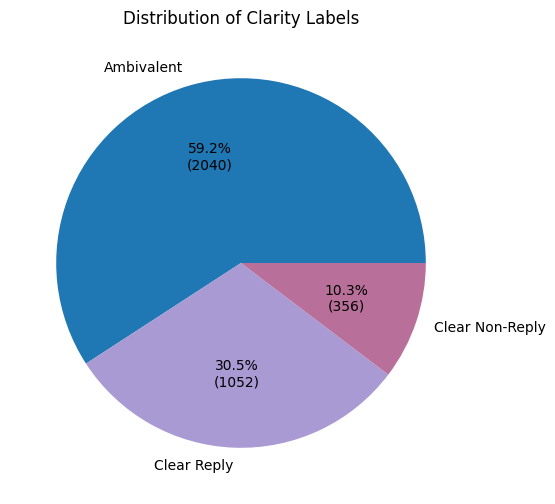

In [6]:
colors = ["#1f77b4", "#a99ad3", "#b8709a"]

df_train["clarity_label"].value_counts().plot(
    kind="pie",
    autopct=lambda p: f"{p:.1f}%\n({int(p*len(df_train)/100)})",
    figsize=(6,6),
    colors=colors
)
plt.title("Distribution of Clarity Labels")
plt.ylabel("")
plt.show()

## Textual Analysis


### Clarity Label Distribution by Word Count

 The dataset contains 3,448 responses, with an average length of approximately 294 words and a high standard deviation (301.54), indicating substantial variability in response length. The distribution is highly skewed, ranging from very short answers (1 word) to very long ones (up to 2,117 words). The median value (207 words) is lower than the mean, suggesting the presence of long outlier responses that increase the average.
 
 Examining the classes separately, Ambivalent responses not only constitute the majority of the dataset (2,040 samples) but also tend to be longer on average (331.86 words) and exhibit the highest variability (standard deviation of 319.53). Clear Reply responses include 1,052 samples with a moderate average length of 272.04 words and a relatively high spread (standard deviation of 269.54). In contrast, Clear Non-Reply responses form the smallest group (356 samples) and are considerably shorter, with an average length of 137.81 words and lower variability (standard deviation of 217.39).

Overall, these results indicate a clear relationship between response length and clarity. Shorter responses are more frequently associated with non-replies, while longer and more variable responses tend to correspond to ambivalent answers. This observation suggests that response length may serve as a useful feature for distinguishing between clarity categories.


=== Statistics by clarity_label ===
                 count        mean  median  min   max         std
clarity_label                                                    
Ambivalent        2040  331.857843   243.5    1  2117  319.526222
Clear Non-Reply    356  137.806180    39.5    1  1407  217.389827
Clear Reply       1052  272.041825   194.0    1  1592  269.540724


<Figure size 800x500 with 0 Axes>

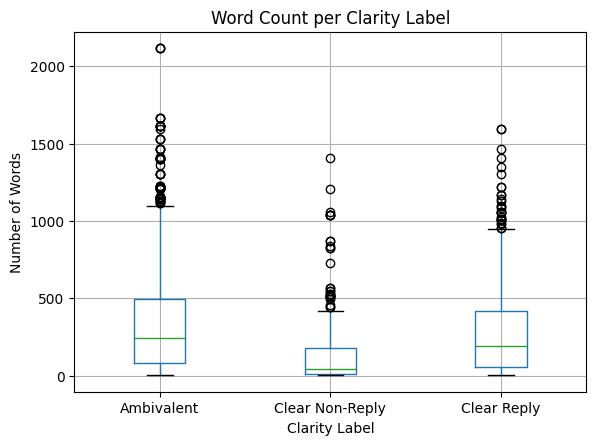

In [7]:
df_train = add_word_count(df_train, "interview_answer", "answer_word_count")
print_label_stats(df_train, "clarity_label", "answer_word_count")
plot_clarity_boxplot(df_train, "answer_word_count", "clarity_label")

To support the textual analyses that follow (pattern detection and spelling checks), the interview question, sub-question, and interview answer are concatenated into a single `text` column for both the train and test sets.

In [8]:
train = df_train[["interview_question", "question", "interview_answer", "clarity_label"]].copy()
train["text"] = (
    train["interview_question"].astype(str) + " " +
    train["question"].astype(str) + " " +
    train["interview_answer"].astype(str)
)

test = df_test[["interview_question", "question", "interview_answer", "clarity_label"]].copy()
test["text"] = (
    test["interview_question"].astype(str) + " " +
    test["question"].astype(str) + " " +
    test["interview_answer"].astype(str)
)


### Detection of Text Patterns in the Dataset
Only numerical patterns were detected in the dataset. Since no strong or meaningful textual patterns were identified, no additional preprocessing is required.

In [9]:
detect_text_patterns(train["text"])
detect_text_patterns(test["text"])


Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 1692 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!
Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 166 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!


### Detection of spelling errors
Spelling errors constitute a very small portion of the dataset, suggesting that the textual data is generally clean and that spelling mistakes are unlikely to significantly affect the performance of the classification models.

In [10]:
check_spelling_errors(train["text"])
find_bad_samples(train["text"], threshold=30)


Total words: 1345446
Misspelled words: 25716
Percentage of misspelled words: 1.91%
Example misspelled words: ['thei', 'chineseno', 'aboutit', 've', 'donei']


The same spelling check is repeated on the test set to confirm that it is equally clean and shares the same characteristics as the training set.


In [11]:
check_spelling_errors(test["text"])
find_bad_samples(test["text"], threshold=30)

Total words: 129505
Misspelled words: 1862
Percentage of misspelled words: 1.44%
Example misspelled words: ['corke', 'nbc', 'll', 'hu', 'jintao']


## Token Analysis 
This analysis was performed mainly to get an overview of how large the input question-answer pairs are when tokenized with the Qwen LLM tokenizer.


In [12]:
model_name = "Qwen/Qwen3.5-0.8B"

tokenizer = Tokenizer.from_pretrained(model_name)

token_counts_train = np.array([
    len(tokenizer.encode(q + "\n" + a).ids)
    for q, a in zip(df_train["question"], df_train["interview_answer"])
])
token_counts_test = np.array([
    len(tokenizer.encode(q + "\n" + a).ids)
    for q, a in zip(df_test["question"], df_test["interview_answer"])
])

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Histogram of the token-length distribution for the **train** set.

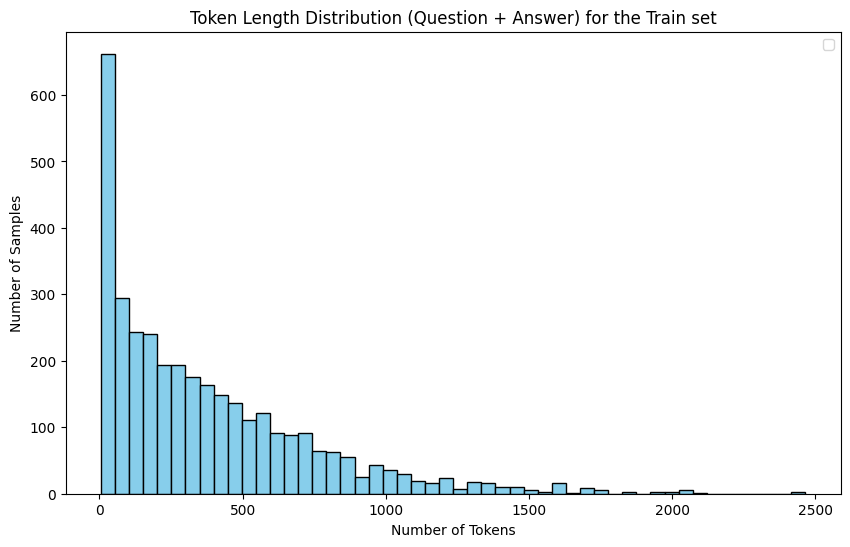

In [13]:
plt.figure(figsize=(10, 6))

# Plot the histogram of token counts
plt.hist(token_counts_train, bins=50, color='skyblue', edgecolor='black')

# Set plot labels and title
plt.title('Token Length Distribution (Question + Answer) for the Train set')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Samples')

# Display the legend to identify the 512-limit line
plt.legend()

plt.show()

Basic token-length statistics (mean, median, min, max) for the **training** set

In [14]:
# Display basic token statistics
print(f"Total samples: {len(token_counts_train)}")
print(f"Mean length: {token_counts_train.mean():.2f}")
print(f"Median length: {np.median(token_counts_train)}")
print(f"Maximum length: {token_counts_train.max()}")
print(f"Minimum length: {token_counts_train.min()}")



Total samples: 3448
Mean length: 376.04
Median length: 273.0
Maximum length: 2465
Minimum length: 5


Histogram of the token-length distribution for the **test** set.

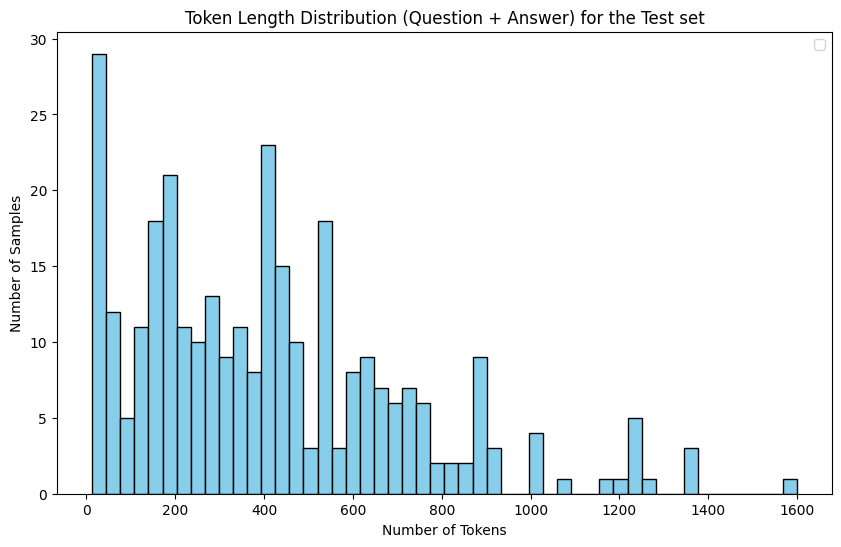

In [15]:
plt.figure(figsize=(10, 6))

# Plot the histogram of token counts
plt.hist(token_counts_test, bins=50, color='skyblue', edgecolor='black')

# Set plot labels and title
plt.title('Token Length Distribution (Question + Answer) for the Test set')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Samples')

# Display the legend to identify the 512-limit line
plt.legend()

plt.show()

Basic token-length statistics (mean, median, min, max) for the **test** set.

In [16]:
# Display basic token statistics
print(f"Total samples: {len(token_counts_test)}")
print(f"Mean length: {token_counts_test.mean():.2f}")
print(f"Median length: {np.median(token_counts_test)}")
print(f"Maximum length: {token_counts_test.max()}")
print(f"Minimum length: {token_counts_test.min()}")



Total samples: 308
Mean length: 412.91
Median length: 379.5
Maximum length: 1599
Minimum length: 13


# Preprocessing
Duplicate rows were then removed from the training set based on the combination of question, interview answer, and clarity label. This ensures that identical question–answer–label triplets do not appear more than once.


## Deduplication

In [3]:
# size before removing duplicates
print("Before drop_duplicates:", df_train.shape)

# remove duplicated rows based on question + answer 
df_train = df_train.drop_duplicates(subset=["question", "interview_answer"])


# size after removing duplicates
print("After drop_duplicates:", df_train.shape)

#labels
LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]


Before drop_duplicates: (3448, 20)
After drop_duplicates: (3390, 20)


## Split dataset
The dataset was split into two parts in order to evaluate D3-Agentic System  under different experiments. The `train_part` subset was kept separate and used only for selecting few-shot examples, while `valid_df` was used as the main experimental evaluation dataset. This separation ensures that the examples shown to the model in few-shot prompting do not overlap with the instances used for evaluation.

The final evaluation dataset remained imbalanced, reflecting the original class distribution. 
The length statistics also show differences between the classes. Ambivalent answers tend to be the longest on average, Clear Reply answers are shorter on average Clear Non-Reply answers are the shortest. This suggests that answer length may be related to the clarity label, especially because non-replies often appear as shorter or more evasive responses.

In [4]:
from sklearn.model_selection import train_test_split

train_part, valid_df = train_test_split(
    df_train,
    test_size=300,                   
    random_state=42,
    stratify=df_train["clarity_label"]
)

train_part = train_part.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(train_part.shape, valid_df.shape)
print(valid_df["clarity_label"].value_counts())

(3090, 20) (300, 20)
clarity_label
Ambivalent         177
Clear Reply         92
Clear Non-Reply     31
Name: count, dtype: int64


## Device

In [5]:
device_manager = DeviceManager()
device_manager.summary()
device = device_manager.device


print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Device type: cuda
Current GPU: Tesla T4
Using 2 GPUs with DataParallel
Python exe: /usr/bin/python3
Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 2


## Model


In [6]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B"


def load_qwen_model(model_name=MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name,trust_remote_code=True, padding_side="left")

    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer, model

qwen_tokenizer, qwen_model = load_qwen_model(MODEL_NAME)
print("Loaded", MODEL_NAME)
n_params = sum(p.numel() for p in qwen_model.parameters())

print(qwen_tokenizer.chat_template is not None)
print(f"Model name: {MODEL_NAME}")
print(f"Total parameters: {n_params:,} ({n_params/1e9:.2f}B)")
print(f"Context length: {qwen_model.config.max_position_embeddings:,} tokens")
print(f"Dtype: {qwen_model.dtype}") 
print(f"Vocab size: {qwen_model.config.vocab_size:,}")


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-0.8B
True
Model name: Qwen/Qwen3.5-0.8B
Total parameters: 752,393,024 (0.75B)
Context length: 262,144 tokens
Dtype: torch.float16
Vocab size: 248,320


# Experiments

**Designing a D3-Agentic System**

D3-Agentic Prompting Pipeline

The proposed system implements a lightweight **D3-Agentic Prompting** pipeline for response clarity classification. The goal of the system is to classify whether a political answer constitutes a **Clear Reply**, an **Ambivalent** response, or a **Clear Non-Reply** with respect to a given target question.

Unlike standard supervised classifiers, the D3-Agentic system does not train or update any model parameters. Instead, it uses the instruction-tuned language model `Qwen/Qwen3.5-0.8B` as a fixed reasoning component. The overall classification problem is decomposed into four smaller and more focused subtasks, each handled by a specialized prompt-based agent.

Therefore, the objective of this part of the experiment is to design and implement these four subtasks appropriately.

Based on this idea, we design four agents:

* **Question Intent Agent**
* **Answer Content Agent**
* **Gap and Evasion Agent**
* **Decision Agent**

Each agent is implemented as a separate call to the loaded Qwen model. The behavior of each agent is controlled through a dedicated prompt that defines its role, input format, expected reasoning task, and output format.



## Example


The following describes each agent through a worked example, presenting the basic prompt and the corresponding response for each agent.


In [9]:
test_q = "Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?"
test_a = "Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes."
test_label = "Ambivalent"

print("Question:", test_q)
print("-" * 50)

print("Answer:", test_a)
print("-" * 50)

print("Label:", test_label)
print("-" * 50)


Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
Label: Ambivalent
--------------------------------------------------


### Question Intent Agent

The Question Intent Agent receives only the target question as input. Its role is to analyze what the question is asking and define what information is required for a clear answer.

The agent returns a structured JSON output containing:

* question_type: the type of the target question, such as yes/no, what, why, how, stance, explanation, or action plan.
* question_intent: a short sentence describing the main intent of the target question.
* must_address: a list of specific points that the answer must address.
* clear_answer_criteria: a sentence describing what a clear answer should contain.
* minimal_sufficient_answer: the minimum information needed for the answer to be classified as a Clear Reply.

This output is then passed to the next agents, helping the pipeline compare the answer against the actual requirements of the target question.


In [7]:
QUESTION_INTENT_PROMPT = """
You are the Question Intent Agent for a response-clarity classification task.

Important dataset rule:
The TARGET_QUESTION may be only one sub-question extracted from a longer interview question.
Analyze ONLY the TARGET_QUESTION. Do not require the answer to address other questions unless they are necessary for this target question.

Your task:
Identify exactly what information would make an answer clear for the TARGET_QUESTION.

Think in terms of answer requirements:
- Is the question asking for yes/no?
- Is it asking what happened?
- Is it asking why/how something happened?
- Is it asking for a specific action, plan, reason, explanation, stance, or evaluation?
- Is it asking about a named person, event, country, policy, organization, or date?

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_type": "yes_no|what|why|how|when|where|who|stance|explanation|action_plan|evaluation|other",
  "question_intent": "one sentence describing what the target question asks",
  "must_address": [
    "specific requirement 1",
    "specific requirement 2"
  ],
  "clear_answer_criteria": "one sentence describing what a clear answer must contain",
  "minimal_sufficient_answer": "short description of the minimum information needed for Clear Reply"
}
""".strip()

print(f"Tokens: {len(qwen_tokenizer.encode(QUESTION_INTENT_PROMPT))}")

Tokens: 292


In [33]:
# ============ Question Agent Response ============
print("Question:", test_q)
print("-" * 50)

question_intent_result = run_question_intent_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=QUESTION_INTENT_PROMPT,
    question=test_q,
    max_new_tokens=300
)

question_intent_agent_json = question_intent_result.copy()
question_intent_raw = question_intent_agent_json.pop("raw", None)

print("=== QUESTION INTENT PARSED JSON ===")
print(json.dumps(question_intent_agent_json, indent=2, ensure_ascii=False))

Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
=== QUESTION INTENT PARSED JSON ===
{
  "question_type": "yes_no|what",
  "question_intent": "Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?",
  "must_address": [
    "specific requirement 1",
    "specific requirement 2"
  ],
  "clear_answer_criteria": "The answer must clearly state whether the speaker is going to ensure that the people will still receive help from the Federal Government to pay the insurance.",
  "minimal_sufficient_answer": "Yes, I am going to ensure that those people will still get help from the Federal Government to pay that insurance."
}


For this question–answer pair, the Question Intent agent gives a clear and specific clear_answer_criteria (it correctly says the answer must show whether the speaker will make sure people keep getting federal help) and a good minimal_sufficient_answer that captures the need for both a yes/no answer and some explanation. But it does not fill in the must_address field — it just copies the template placeholders instead of writing the real requirements. The question_type value ("yes_no|what") has the same problem: it copies the list of options from the prompt instead of choosing one type. 

In [20]:
print(f"Tokens: {len(qwen_tokenizer.encode(question_intent_raw))}")

Tokens: 137


### Answer Content Agent

The Answer Content Agent receives both the target question and the interview answer as input. Its role is to describe neutrally what the answer actually contains, without making the final classification decision.

The agent returns a structured JSON output containing:

* direct_answer_present: whether the answer includes a direct response to the target question.
* direct_answer_summary: a short summary of the direct answer, or "none" if no direct answer is present.
* concrete_information: a list of specific on-topic facts, claims, names, numbers, or positions mentioned in the answer.
* vague_or_general_information: a list of statements that are related to the target question but remain vague or general.
* off_target_content: parts of the answer that respond to a different question or shift the topic.
* refusal_or_non_answer_signals: any signals that the speaker refuses or declines to answer.

This output helps the following agents understand what the answer says before comparing it with the requirements of the target question.


In [8]:
ANSWER_CONTENT_PROMPT = """
You are the Answer Content Agent for a response-clarity classification task.

Important dataset rule:
The answer may respond to a longer interview question, but you must evaluate what it says with respect to the TARGET_QUESTION only.

Your task:
Extract what the answer actually says that is relevant to the TARGET_QUESTION.

Do not decide the final label.
Do not reward political rhetoric unless it answers the target question.
Do not infer facts that are not present in the answer.
An implicit answer is allowed only if the answer gives enough information to resolve the target question.

Look for:
direct answer phrases: yes, no, I did, I did not, we will, we will not, because...
concrete facts, actions, reasons, explanations, examples, commitments
vague but related statements
topic shifts
refusals or declines to answer
answers to a different sub-question

Return exactly one JSON object and nothing else.

JSON schema:
{
  "relevant_answer_summary": "one sentence summarizing only content relevant to the target question",
  "direct_answer_present": true,
  "direct_answer_text": "exact short phrase if present, otherwise empty string",
  "concrete_information": [
    "concrete relevant point 1",
    "concrete relevant point 2"
  ],
  "vague_or_general_information": [
    "vague/general relevant point 1"
  ],
  "off_target_content": [
    "content that answers a different question or changes topic"
  ],
  "refusal_or_non_answer_signals": [
    "signal 1"
  ]
}
""".strip()

print(f"Tokens: {len(qwen_tokenizer.encode(ANSWER_CONTENT_PROMPT))}")

Tokens: 349


In [35]:
# ============ Answer Agent Response ============

print("Question:", test_q)
print("-" * 50)
print("Answer:", test_a)
print("-" * 50)

answer_content_result = run_answer_content_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=ANSWER_CONTENT_PROMPT,
    question=test_q,
    answer=test_a,
    max_new_tokens=500
)

answer_content_agent_json= answer_content_result.copy()
answer_content_raw = answer_content_agent_json.pop("raw", None)

print("=== ANSWER CONTENT PARSED JSON ===")
print(json.dumps(answer_content_agent_json, indent=2, ensure_ascii=False))


Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
=== ANSWER CONTENT PARSED JSON ===
{
  "relevant_answer_summary": "The speaker confirms that the goal is to ensure people will still get help from the Federal Government 

In this example, the Answer Content Agent correctly detects the explicit "Yes." at the end of the answer and reports it as the direct answer. However, it makes the answer look cleaner and more on-target than it really is. The off_target_content is left empty even though much of the answer is political rhetoric and topic drift (criticism of Obamacare, references to states the speaker won or lost) that does not address whether federal help to pay insurance will continue. As a result, the agent under-reports the evasive parts of the answer, which can push the downstream classifier toward "Clear Reply" on a response that is arguably closer to "Ambivalent".

In [23]:
print(f"Tokens: {len(qwen_tokenizer.encode(answer_content_raw))}")

Tokens: 185


### Gap and Evasion Agent

The Gap and Evasion Agent receives the target question, the interview answer, the Question Intent Agent output, and the Answer Content Agent output. Its role is to compare what the question requires with what the answer actually provides.

The agent returns a structured JSON output containing:

* coverage: how much of the target question is covered by the answer, ranging from complete to none.
* gap_level: the severity of the missing information, such as none, minor, partial, or major.
* best_evasion_category: the type of response behavior( explicit answer, implicit answer, partial answer, general answer, dodging, deflection, refusal, ignorance claim, clarification only, or irrelevant response).
* missing_requirements: the specific requirements from the target question that were not answered.
* evidence_for_answering: short evidence showing which parts of the answer address the question.
* evidence_for_evasion_or_gap: short evidence showing vagueness, avoidance, incompleteness, or off-topic content.
* gap_explanation: a concise explanation of the main gap between the question and the answer.

This output helps the Decision Agent understand whether the answer fully addresses the target question or whether it is incomplete, vague, indirect, or evasive.


In [9]:
GAP_EVASION_PROMPT = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. the Question Intent Agent output,
4. the Answer Content Agent output.

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "missing requirement 1"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()

print(f"Tokens: {len(qwen_tokenizer.encode(GAP_EVASION_PROMPT))}")

Tokens: 455


In [37]:
# ============ Gap Evasion Agent Response ============
print("Question:", test_q)
print("-" * 50)

print("Answer:", test_a)
print("-" * 50)

gap_evasion_result = run_gap_evasion_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=GAP_EVASION_PROMPT,
    question=test_q,
    answer=test_a,
    question_intent=question_intent_agent_json,
    answer_content=answer_content_agent_json,
    max_new_tokens=600
)

gap_evasion_json = gap_evasion_result.copy()
gap_evasion_raw = gap_evasion_json.pop("raw", None)

print("=== GAP EVASION PARSED JSON ===")
print(json.dumps(gap_evasion_json, indent=2, ensure_ascii=False))


Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
=== GAP EVASION PARSED JSON ===
{
  "coverage": "mostly_complete",
  "gap_level": "minor",
  "best_evasion_category": "explicit_answer",
  "missing_requirements": [
    "

In this example, the Gap and Evasion Agent still mainly repeats and amplifies errors from the earlier agents. It fails to recognise that “Specific requirement 2” is only an empty placeholder and instead treats it as a real requirement about the payment mechanism. More importantly, it presents the upstream minimal_sufficient_answer as if it were evidence quoted from the actual response, even though the speaker only gives a plain “Yes.” Because of this, the agent overestimates the answer’s completeness, assigns overly generous scores, and pushes the final pipeline toward an incorrect Clear Reply prediction.

In [26]:
print(f"Tokens: {len(qwen_tokenizer.encode(gap_evasion_raw))}")

Tokens: 193


During the inspection of the raw Gap and Evasion Agent outputs, I noticed that the model did not always return valid JSON. In some cases, the generated content was useful, but the JSON structure was incomplete. For example, the model sometimes omitted a final closing bracket or brace.

This could create problems for the pipeline, because if the Gap Agent output could not be parsed correctly, the parsed result might become empty or remain available only as raw text. As a result, the Decision Agent would receive incomplete intermediate information, which could negatively affect the final classification.

To make the pipeline more robust, I implemented a more flexible JSON parsing function. The parser first attempts to read the model output directly as JSON. If this fails, it searches inside the generated text for a JSON object and tries to parse the largest possible valid part. If the extracted JSON still appears incomplete, the helper function \texttt{_close_json} attempts to repair it by closing missing quotes, lists, or dictionaries.

If all parsing attempts fail, the pipeline does not crash. Instead, the original model output is stored under the \texttt{raw} field. This makes the system more robust to malformed model outputs and also makes debugging easier, since the original response is still preserved.


### Decision Agent

The Decision Agent receives the target question, the interview answer, and the intermediate outputs from the previous agents. Its role is to assign the final response-clarity label.

The agent returns a structured JSON output containing:

* label: the final predicted class, which can be Clear Reply, Ambivalent, or Clear Non-Reply.
* confidence: a confidence score for the assigned label.
* main_reason: a concise explanation of why this label was selected.
* used_rule: the main decision rule that led to the final classification.

The Decision Agent uses the gap analysis and the answer requirements to determine whether the answer fully resolves the target question, partially addresses it, or fails to provide meaningful information. Complete or mostly complete answers are classified as Clear Reply, partially relevant but insufficient answers as Ambivalent, and refusals, deflections, irrelevant responses, or answers with no useful information as Clear Non-Reply.


In [10]:

DECISION_PROMPT = """
You are the Decision Agent for CLARITY response classification.

Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:

Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.

Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.

Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- If coverage is complete or mostly_complete and the answer resolves the target question -> Clear Reply.
- If coverage is partial/minimal but there is relevant information -> Ambivalent.
- If coverage is none, or the response is mainly refusal/deflection/irrelevant -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Few-shot calibration examples:

Example A:
Target question: "Did you support the bill?"
Answer content: "Yes, I voted for it and I still support it."
Gap analysis: coverage complete; explicit answer.
Final label: Clear Reply.

Example B:
Target question: "What specific steps will you take to reduce prices?"
Answer content: "Families are struggling, this is important, and we are working every day."
Gap analysis: relevant but no specific steps.
Final label: Ambivalent.

Example C:
Target question: "Did you meet with the ambassador?"
Answer content: "I am not going to discuss private diplomatic conversations."
Gap analysis: declining to answer; no requested information.
Final label: Clear Non-Reply.

Example D:
Target question: "Why did unemployment increase?"
Answer content: "The economy has faced global pressure, energy shocks, and reduced demand."
Gap analysis: gives reasons even without saying 'because'.
Final label: Clear Reply.

Example E:
Target question: "Do you think President X is sincere?"
Answer content: "I am sincere about improving the relationship."
Gap analysis: answers the speaker's sincerity, not President X's sincerity.
Final label: Ambivalent.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

print(f"Tokens: {len(qwen_tokenizer.encode(DECISION_PROMPT))}")

Tokens: 814


In [39]:
# ============ Decision Agent Response ============
print("Question:", test_q)
print("-" * 50)

print("Answer:", test_a)
print("-" * 50)

decision_result = run_decision_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=DECISION_PROMPT,
    question=test_q,
    answer=test_a,
    question_intent=question_intent_agent_json,
    answer_content=answer_content_agent_json,
    gap_evasion=gap_evasion_json,
    max_new_tokens=200
)

decision_json = decision_result.copy()
decision_raw = decision_json.pop("raw", None)

print("=== DECISION PARSED JSON ===")
print(json.dumps(decision_json, indent=2, ensure_ascii=False))



Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
=== DECISION PARSED JSON ===
{
  "label": "Clear Reply",
  "confidence": 0.95,
  "rationale": "The answer directly and explicitly confirms the speaker's intention to ensu

In this final step, the Decision Agent outputs the label Clear Reply with very high confidence (0.95). This is the end result of the error cascade described above: because the earlier agents removed or hid the evasive parts of the answer, the Decision Agent sees only a clean affirmative and treats the single “Yes” at the end as a full, unambiguous reply. Its rationale again restates the wording of the question as if the speaker had explicitly confirmed it, and its used_rule claims there is no ambiguity or refusal, even though most of the answer is rhetoric and deflection that never directly addresses the federal-help question. The outcome is therefore not only an incorrect prediction (Clear Reply instead of Ambivalent) but an overconfident one, which shows how the pipeline can become very sure of a wrong answer once the ambiguity signal has been lost in the earlier stages.

In [29]:
print(f"Tokens: {len(qwen_tokenizer.encode(decision_raw))}")

Tokens: 127


# First Set Of Experiments
## Baseline 
### Experiment 1

As a baseline experiment, the agent prompts were kept unchanged and the D3 pipeline was evaluated on the valid_df validation dataframe.

In [ ]:

d3_full_val1 = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt=QUESTION_INTENT_PROMPT,
    answer_content_prompt=ANSWER_CONTENT_PROMPT,
    gap_evasion_prompt=GAP_EVASION_PROMPT,
    decision_prompt=DECISION_PROMPT,
    
    use_question_intent=True,
    use_answer_content=True,
    use_gap_evasion=True,

    pred_col_name="pred_d3",
    variant_name="Full D3",

    limit=None,
    batch_size=8,

    max_tokens_question_intent=250,
    max_tokens_answer_content=450,
    max_tokens_gap_evasion=600,
    max_tokens_decision=200
)




Full D3 | Question Intent Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 | Answer Content Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 | Gap/Evasion Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 | Decision Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.36      0.39        92
     Ambivalent       0.61      0.75      0.67       177
Clear Non-Reply       0.43      0.10      0.16        31

       accuracy                           0.56       300
      macro avg       0.49      0.40      0.41       300
   weighted avg       0.54      0.56      0.53       300



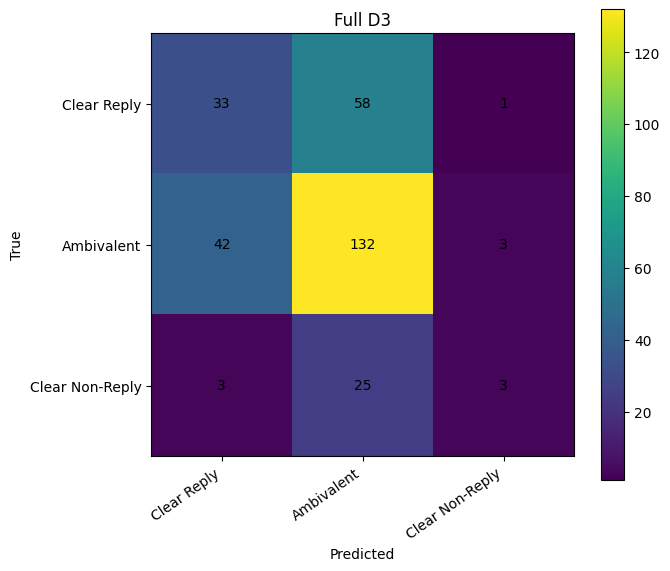

In [ ]:

experiments = [
    {
        "name": "Full D3",
        "df": d3_full_val1,
        "pred_col": "pred_d3"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

## Ablation Experiments

### Experiment 2 No Gap/Evasion Agent

Here we perform a test the ablation variant without the Gap/Evasion Agent, we modified the downstream prompts  so that they no longer depend on the gap analysis output. In this setting, the Decision Agent directly compares the Question Intent output, the Answer Content output, and the original answer in order to assign the final clarity label.

In [ ]:
DECISION_PROMPT_noGap = """
You are the Decision Agent for CLARITY response classification.

Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. 
If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:

Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.

Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.

Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- Compare the Question Intent output with the Answer Content output and the raw answer.
- If the answer directly or implicitly satisfies the required information from the target question -> Clear Reply.
- If the answer gives relevant information but is incomplete, vague, generic, or only partially satisfies the target question -> Ambivalent.
- If the answer gives little or no usable information for the target question, refuses to answer, redirects, or answers a different question -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Few-shot calibration examples:

Example A:
Target question: "Did you support the bill?"
Answer content: "Yes, I voted for it and I still support it."
Final label: Clear Reply.

Example B:
Target question: "What specific steps will you take to reduce prices?"
Answer content: "Families are struggling, this is important, and we are working every day."
Final label: Ambivalent.

Example C:
Target question: "Did you meet with the ambassador?"
Answer content: "I am not going to discuss private diplomatic conversations."
Final label: Clear Non-Reply.

Example D:
Target question: "Why did unemployment increase?"
Answer content: "The economy has faced global pressure, energy shocks, and reduced demand."
Final label: Clear Reply.

Example E:
Target question: "Do you think President X is sincere?"
Answer content: "I am sincere about improving the relationship."
Final label: Ambivalent.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()



In [ ]:
d3_no_gap_val = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt=QUESTION_INTENT_PROMPT,
    answer_content_prompt=ANSWER_CONTENT_PROMPT,
    gap_evasion_prompt=None,
    decision_prompt=DECISION_PROMPT_noGap,

    use_question_intent=True,
    use_answer_content=True,
    use_gap_evasion=False,

    pred_col_name="pred_d3_no_gap",
    variant_name="D3 without Gap Agent",

    limit=None,
    batch_size=8,

    max_tokens_question_intent=250,
    max_tokens_answer_content=500,
    max_tokens_gap_evasion=600,
    max_tokens_decision=200
)



D3 without Gap Agent | Question Intent Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 without Gap Agent | Answer Content Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 without Gap Agent | Decision Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 without Gap Agent
                 precision    recall  f1-score   support

    Clear Reply       0.42      0.68      0.52        92
     Ambivalent       0.63      0.52      0.57       177
Clear Non-Reply       0.60      0.10      0.17        31

       accuracy                           0.53       300
      macro avg       0.55      0.43      0.42       300
   weighted avg       0.56      0.53      0.51       300



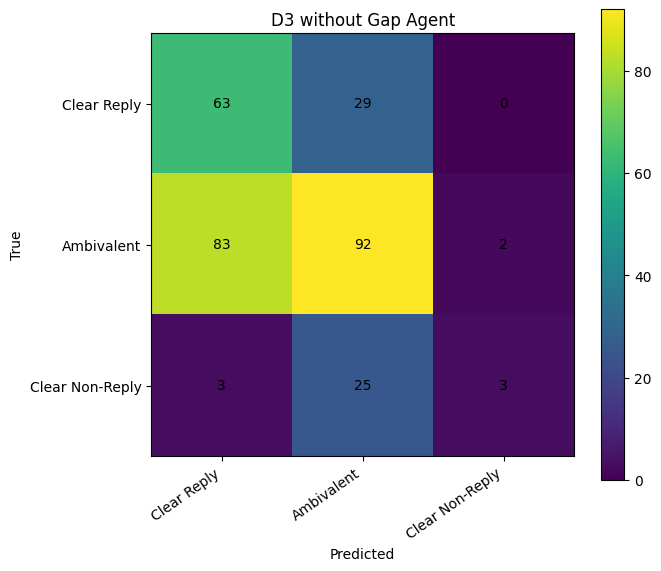

In [ ]:
experiments = [
    {
        "name": "D3 without Gap Agent",
        "df": d3_no_gap_val,
        "pred_col": "pred_d3_no_gap"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

### Experiment 3 Merged agents 

To reduce error propagation and the number of LLM calls, the Question Intent Agent and the Answer Content Agent are merged into a single **Question–Answer Content Agent**. It receives the target question and the answer together and produces one structured description of how the answer relates to the question. The prompt keeps the dataset rule that the target question may be only a sub-question of a longer interview question, and frames the task as a neutral, structural description rather than a judgment.


In [ ]:
QUESTION_ANSWER_CONTENT_PROMPT  = """
You are the Question-Answer Content Agent for a response-clarity classification task.

You are given a TARGET_QUESTION and an ANSWER.

Your job is to describe, neutrally and structurally, how the answer relates to the target question.

Important dataset rule:
The TARGET_QUESTION may be only one sub-question extracted from a longer interview question.
Analyze ONLY the TARGET_QUESTION and the ANSWER given here.
Do not require the answer to address other questions.

Your task:

* Identify what the TARGET_QUESTION is asking for.
* Identify whether the ANSWER contains an explicit response to that target question.
* Extract only the parts of the ANSWER that are relevant to the target question.
* Extract any concrete facts, names, dates, actions, reasons, or positions stated in the ANSWER.
* Separate relevant content from general background or filler.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_focus": "one sentence describing what the target question asks",
  "expected_answer_type": "yes_no|what|why|how|when|where|who|stance|explanation|action_plan|evaluation|other",
  "must_address": [
    "specific requirement 1",
    "specific requirement 2"
  ],
  "explicit_response_present": true,
  "explicit_response_summary": "one sentence describing the explicit response, or 'none'",
  "relevant_answer_content": [
    "specific answer content that relates to the target question"
  ],
  "concrete_details": [
    "specific fact, name, date, number, action, reason, or position stated in the answer"
  ],
  "general_or_filler_content": [
    "answer content that is vague, generic, background, or not directly tied to the target question"
  ]
}
""".strip()

In [ ]:
# ============ Example ============

print("Question:", test_q)
print("-" * 50)
print("Answer:", test_a)
print("-" * 50)

answer_content_result = run_answer_content_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=QUESTION_ANSWER_CONTENT_PROMPT,
    question=test_q,
    answer=test_a,
    max_new_tokens=500
)

answer_content_agent_json_1 = answer_content_result.copy()
answer_content_raw_1 = answer_content_agent_json_1.pop("raw", None)

print("=== PARSED JSON ===")
print(json.dumps(answer_content_agent_json_1, indent=2, ensure_ascii=False))


Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
=== PARSED JSON ===
{
  "question_focus": "Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?",
  "expected_

In [56]:
# small changes 

GAP_EVASION_PROMPT_merged = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. The Question-Answer Content Agent output

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "missing requirement 1"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()



In [ ]:
#============== Experiment ========================================
d3_mergedQA_val = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt= None,
    answer_content_prompt= QUESTION_ANSWER_CONTENT_PROMPT,
    gap_evasion_prompt=GAP_EVASION_PROMPT_merged,
    decision_prompt=DECISION_PROMPT,

    use_question_intent=False,
    use_answer_content=True,
    use_gap_evasion=True,

    pred_col_name="pred_d3_mergedQA",
    variant_name="D3 with Merged Q-A Agent",

    limit=None,
    batch_size=8,

    max_tokens_question_intent=400,
    max_tokens_answer_content=500,
    max_tokens_gap_evasion=500,
    max_tokens_decision=200
)

D3 with Merged Q-A Agent | Answer Content Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 with Merged Q-A Agent | Gap/Evasion Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 with Merged Q-A Agent | Decision Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 with Merged Q-A Agent
                 precision    recall  f1-score   support

    Clear Reply       0.35      0.48      0.41        92
     Ambivalent       0.61      0.60      0.60       177
Clear Non-Reply       0.50      0.03      0.06        31

       accuracy                           0.50       300
      macro avg       0.49      0.37      0.36       300
   weighted avg       0.52      0.50      0.49       300



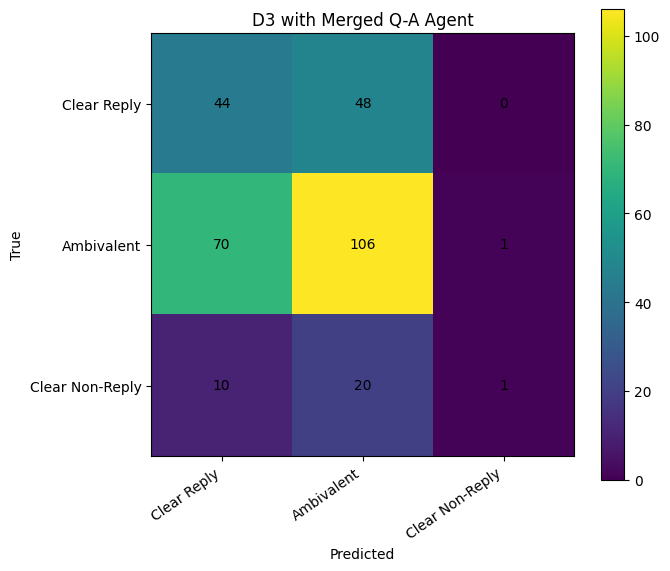

In [ ]:

experiments = [
    {
        "name": "D3 with Merged Q-A Agent",
        "df": d3_mergedQA_val,
        "pred_col": "pred_d3_mergedQA"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

## Prompt formulation

### Experiment 4 Revised Question Agent

In this revised version of the **Question Intent Agent**, the `must_address` field is removed. In the previous version this field used the placeholders "specific requirement 1/2", which the small 0.8B model often copied verbatim and which then propagated as fake requirements through the rest of the pipeline. The requirement information is now expressed directly as a single `clear_answer_criteria` sentence, which is far less prone to placeholder echoing. The prompt also adds positive guidance ("Is the question asking for yes/no? what/why/how? a specific action, plan, reason, stance, or evaluation?") to help the model reason about the answer type.

In [59]:

# ============ PROMPT ============
QUESTION_INTENT_PROMPT_Revised = """
You are the Question Intent Agent for a response-clarity classification task.

Analyze ONLY the TARGET_QUESTION. Identify exactly what information
would make an answer clear.

Think in terms of answer requirements:
- Is the question asking for yes/no?
- Is it asking what / why / how something happened?
- Is it asking for a specific action, plan, reason, stance, or evaluation?

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_type": "yes_no|what|why|how|when|where|who|stance|explanation|action_plan|evaluation|other",
  "question_intent": "one sentence describing what the target question asks",
  "clear_answer_criteria": "one sentence describing what a clear answer must contain",
  "minimal_sufficient_answer": "minimum information needed for Clear Reply"
}
""".strip()




In [ ]:
# ============ Example ============
print("Question:", test_q)
print("-" * 50)

question_intent_result = run_question_intent_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=QUESTION_INTENT_PROMPT_Revised,
    question=test_q,
    max_new_tokens=300
)

question_intent_agent_json_1 = question_intent_result.copy()
question_intent_raw_1 = question_intent_agent_json_1.pop("raw", None)

print("=== QUESTION INTENT PARSED JSON ===")
print(json.dumps(question_intent_agent_json_1, indent=2, ensure_ascii=False))

Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
=== QUESTION INTENT PARSED JSON ===
{
  "question_type": "yes_no",
  "question_intent": "Are you committed to ensuring that the Federal Government will continue to provide financial assistance to those individuals?",
  "clear_answer_criteria": "The answer must explicitly state whether the speaker is going to or not going to ensure that the Federal Government will pay the insurance.",
  "minimal_sufficient_answer": "Yes, I am going to ensure that the Federal Government will pay the insurance."
}


In [60]:
#==========Experiment==============================================

d3_full_val_smaller_Qagent = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt=QUESTION_INTENT_PROMPT_Revised,
    answer_content_prompt=ANSWER_CONTENT_PROMPT,
    gap_evasion_prompt=GAP_EVASION_PROMPT,
    decision_prompt=DECISION_PROMPT,

    use_question_intent=True,
    use_answer_content=True,
    use_gap_evasion=True,

    pred_col_name="pred_d3_Q",
    variant_name="Full D3 Revised Question Agent",

    limit=None,
    batch_size=8,

    max_tokens_question_intent=250,
    max_tokens_answer_content=500,
    max_tokens_gap_evasion=600,
    max_tokens_decision=200
)



Full D3 Revised Question Agent | Question Intent Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question Agent | Answer Content Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question Agent | Gap/Evasion Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question Agent | Decision Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question Agent
                 precision    recall  f1-score   support

    Clear Reply       0.40      0.39      0.40        92
     Ambivalent       0.61      0.70      0.65       177
Clear Non-Reply       0.44      0.13      0.20        31

       accuracy                           0.55       300
      macro avg       0.49      0.41      0.42       300
   weighted avg       0.53      0.55      0.53       300



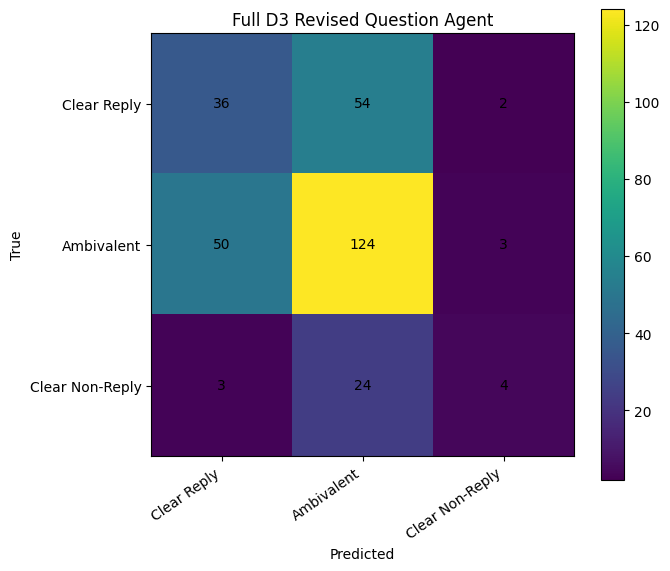

In [ ]:
experiments = [
    {
        "name": "Full D3 Revised Question Agent",
        "df": d3_full_val_smaller_Qagent,
        "pred_col": "pred_d3_Q"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

### Experiment 5 Revised  Answer Agent


The Answer Content Agent describes, with respect to the target question only, what the answer actually contains, without assigning the final label. The revised prompt strengthens this role with several guards: it must not reward political rhetoric unless it answers the question, must not infer facts that are not present, and it applies a strict definition of a direct answer — a response counts as direct only if it explicitly states yes or no, and any extra information must genuinely address the question, otherwise the response is not treated as direct. The output schema keeps the direct answer as an exact short phrase (`direct_answer_text`) rather than a paraphrase, separates on-topic `concrete_information` from `off_target_content` (rhetoric, filler, topic shifts), and adds a `refusal_or_non_answer_signals` field that is useful for the Clear Non-Reply class, together with a `stated_position` field. A one-shot example is included to show the model that political rhetoric should go into `off_target_content` while only the genuine commitment is kept as the direct answer. Together these changes target the earlier failures, where the agent left off-target content empty and restated the question's wording as if it were content from the answer.

In [11]:
ANSWER_CONTENT_PROMPT_Revised = """
You are the Answer Content Agent for a response-clarity classification task.

Important dataset rule:
The answer may respond to a longer interview question, but you must evaluate what it says with respect to the TARGET_QUESTION only.

Your task:
Extract what the answer actually says that is relevant to the TARGET_QUESTION.

Do not decide the final label.
Do not reward political rhetoric unless it answers the target question.
Do not infer facts that are not present in the answer.
A response counts as a direct answer only if it explicitly states yes or no.
If it adds further information, that information must actually address the
question; if the extra content is off-topic or general, the response does NOT
count as a direct answer.

Look for:
concrete facts, actions, reasons, explanations, examples, commitments
vague but related statements
topic shifts
refusals or declines to answer
answers to a different sub-question


JSON schema:
{
  "direct_answer_present": true,
  "direct_answer_text": "exact short phrase from the answer, or empty string",
  "concrete_information": ["specific on-topic point actually stated in the answer"],
  "off_target_content": ["vague, off-topic, rhetorical, or filler part"],
  "refusal_or_non_answer_signals": ["signal that the speaker refuses/declines, else empty list"],
  "stated_position": "the speaker's explicitly stated position, or 'none'"
}

Example:
TARGET_QUESTION: Will you raise the minimum wage?
ANSWER: Look, the previous government destroyed this economy, it was a total disaster.
We care about working families more than anyone ever has. Yes, we will raise it.
Output:
{
  "direct_answer_present": true,
  "direct_answer_text": "Yes, we will raise it.",
  "concrete_information": ["The speaker commits to raising the minimum wage."],
  "off_target_content": ["Attack on the previous government ('destroyed this economy', 'a total disaster')", "General claim about caring for working families"],
  "refusal_or_non_answer_signals": [],
  "stated_position": "In favor of raising the minimum wage."
}
""".strip()


In [45]:
# ============ Example ============
print("Question:", test_q)
print("-" * 50)
print("Answer:", test_a)
print("-" * 50)

answer_content_result = run_answer_content_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=ANSWER_CONTENT_PROMPT_Revised,
    question=test_q,
    answer=test_a,
    max_new_tokens=500
)

# Separate parsed JSON from raw model output
answer_content_agent_json_2 = answer_content_result.copy()
answer_content_raw_2 = answer_content_agent_json_2.pop("raw", None)

print("=== ANSWER CONTENT PARSED JSON ===")
print(json.dumps(answer_content_agent_json_2, indent=2, ensure_ascii=False))


Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
=== ANSWER CONTENT PARSED JSON ===
{
  "direct_answer_present": true,
  "direct_answer_text": "Yes",
  "concrete_information": [
    "The speaker states that the goal is 

In [ ]:
#====================Experiment ======================
d3_full_revised_QAagent = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt=QUESTION_INTENT_PROMPT,
    answer_content_prompt=ANSWER_CONTENT_PROMPT_Revised,
    gap_evasion_prompt=GAP_EVASION_PROMPT,
    decision_prompt=DECISION_PROMPT,

    use_question_intent=True,
    use_answer_content=True,
    use_gap_evasion=True,

    pred_col_name="pred_d3_QA",
    variant_name="Full D3 Revised Answer Agent",

    limit=None,
    batch_size=8,

    max_tokens_question_intent=250,
    max_tokens_answer_content=500,
    max_tokens_gap_evasion=600,
    max_tokens_decision=200
)

Full D3 Revised Question and Answer Agent | Question Intent Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question and Answer Agent | Answer Content Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question and Answer Agent | Gap/Evasion Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Question and Answer Agent | Decision Agent:   0%|          | 0/38 [00:00<?, ?it/s]

Full D3 Revised Answer Agent
                 precision    recall  f1-score   support

    Clear Reply       0.48      0.32      0.38        92
     Ambivalent       0.63      0.79      0.70       177
Clear Non-Reply       0.50      0.32      0.39        31

       accuracy                           0.59       300
      macro avg       0.54      0.47      0.49       300
   weighted avg       0.57      0.59      0.57       300



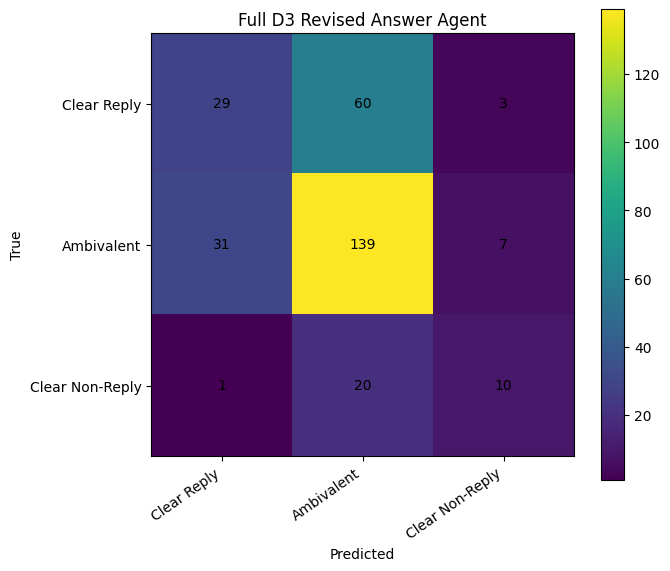

In [ ]:
experiments = [
    {
        "name": "Full D3 Revised Answer Agent",
        "df": d3_full_revised_QAagent,
        "pred_col": "pred_d3_QA"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

### Experiment 6 Revised Gap Agent

The Gap and Evasion Agent compares what the target question requires with what the answer actually provides, and classifies the type and size of any gap, without assigning the final label. The most important change in this version is the primary-evidence rule: the agent must base its judgment mainly on the target question, the Question Intent requirements, and the RAW answer text, and treat the Answer Content output as only an auxiliary hint that may be incomplete or over-optimistic; if the two conflict, it must trust the raw answer. This directly addresses the earlier failure, where the agent inherited the over-optimistic Answer Content analysis and judged an evasive answer as clear. The prompt also defines graded gap levels (minor / partial / major) and a richer set of evasion categories (such as general_answer, dodging, deflection, declining_to_answer, and irrelevant), which gives the pipeline a finer signal for separating Ambivalent answers from Clear Non-Reply ones. Finally, the evidence fields are now required to come from the answer itself, which reduces the earlier problem of presenting upstream generated text as if it were a real quote from the speaker.

In [65]:
GAP_EVASION_PROMPT_ROBUST = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. the Question Intent Agent output,
4. the Answer Content Agent output.

Primary evidence rule (IMPORTANT):
Base your coverage and gap judgment PRIMARILY on the TARGET_QUESTION, the Question Intent requirements (must_address), and the RAW answer text.
The Answer Content Agent output is only an auxiliary hint and may be incomplete or over-optimistic.
If it conflicts with the raw answer, trust the raw answer.
Do not conclude the answer is clear just because the Answer Content analysis describes it positively.

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": ["missing requirement 1"],
  "evidence_for_answering": ["short evidence from the answer"],
  "evidence_for_evasion_or_gap": ["short evidence from the answer"],
  "gap_explanation": "one concise sentence"
}
""".strip()



In [47]:
# ============ Example ============
print("Question:", test_q)
print("-" * 50)

print("Answer:", test_a)
print("-" * 50)

gap_evasion_result = run_gap_evasion_agent(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    system_prompt=GAP_EVASION_PROMPT_ROBUST,
    question=test_q,
    answer=test_a,
    question_intent=question_intent_agent_json,
    answer_content=answer_content_agent_json,
    max_new_tokens=600
)

gap_evasion_json_1 = gap_evasion_result.copy()
gap_evasion_raw = gap_evasion_json_1.pop("raw", None)

print("=== GAP EVASION PARSED JSON ===")
print(json.dumps(gap_evasion_json_1, indent=2, ensure_ascii=False))


Question: Are you going to ensure that those people will still get help from the Federal Government to pay that insurance?
--------------------------------------------------
Answer: Well, that's what we're looking to do, Joe [Jonathan Karl, ABC News]. We want to get it down so that people can have affordable health care. Look, you look at some States—116 percent up. In Alaska, over 200 percent up. In other States, 50 percent, 70 percent up, and those are some of the States that are doing better. Obamacare is a wreck, it's a mess, it's destroying lives. We want to get it in those States—the States that I did so well in—but also in States that I didn't win.I want to get health care that's much more affordable and much better health care, and that's what we're doing.Yes.
--------------------------------------------------
=== GAP EVASION PARSED JSON ===
{
  "coverage": "mostly_complete",
  "gap_level": "minor",
  "best_evasion_category": "explicit_answer",
  "missing_requirements": [
    "

In [ ]:
#================== Experiemnt =========================================
d3_gaprobust_val = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt=QUESTION_INTENT_PROMPT,
    answer_content_prompt=ANSWER_CONTENT_PROMPT,
    gap_evasion_prompt=GAP_EVASION_PROMPT_ROBUST,   
    decision_prompt=DECISION_PROMPT,

    use_question_intent=True,
    use_answer_content=True,
    use_gap_evasion=True,

    pred_col_name="pred_d3_gaprobust",
    variant_name="D3 Gap robust to Answer Agent",

    limit=None, batch_size=8,
    max_tokens_question_intent=250,
    max_tokens_answer_content=500,
    max_tokens_gap_evasion=600,
    max_tokens_decision=200
)


D3 Gap robust to Answer Agent | Question Intent Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 Gap robust to Answer Agent | Answer Content Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 Gap robust to Answer Agent | Gap/Evasion Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 Gap robust to Answer Agent | Decision Agent:   0%|          | 0/38 [00:00<?, ?it/s]

D3 Gap robust to Answer Agent
                 precision    recall  f1-score   support

    Clear Reply       0.39      0.61      0.47        92
     Ambivalent       0.62      0.52      0.57       177
Clear Non-Reply       0.57      0.13      0.21        31

       accuracy                           0.51       300
      macro avg       0.53      0.42      0.42       300
   weighted avg       0.54      0.51      0.50       300



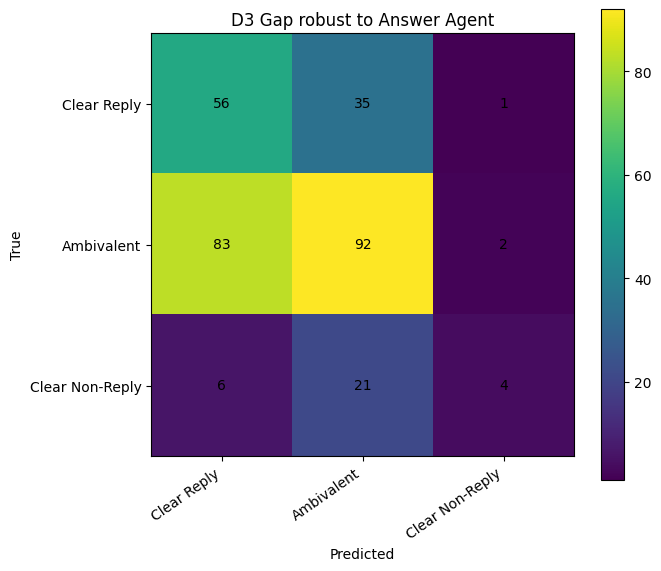

In [ ]:

experiments = [
    {
        "name": "D3 Gap robust to Answer Agent",
        "df": d3_gaprobust_val,
        "pred_col": "pred_d3_gaprobust"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

# First Evaluation 

In [68]:
LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

experiments = [
    {"name": "Full D3",                              "df": d3_full_val1,                "pred_col": "pred_d3"},
    {"name": "D3 without Gap Agent",                 "df": d3_no_gap_val,              "pred_col": "pred_d3_no_gap"},
    {"name": "D3 with Merged Q-A Agent",             "df": d3_mergedQA_val,            "pred_col": "pred_d3_mergedQA"},
    {"name": "Full D3 - Revised Question Intent Agent","df": d3_full_val_smaller_Qagent,"pred_col": "pred_d3_Q"},
    {"name": "Full D3 - Revised Answer Agent",          "df": d3_full_revised_QAagent,    "pred_col": "pred_d3_QA"},
    {"name": "D3 Gap robust to Answer Agent",        "df": d3_gaprobust_val,           "pred_col": "pred_d3_gaprobust"},

]

In [69]:
all_scores = []

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    scores = evaluate_predictions(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        model_name=name,
        labels=LABELS
    )
    all_scores.append(scores)


scores_df = pd.DataFrame(all_scores)

scores_df = scores_df.sort_values(
    "f1_weighted",
    ascending=False
).reset_index(drop=True)

scores_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Full D3 - Revised Answer Agent,0.593333,0.536704,0.474370,0.491087,0.571934,0.593333,0.570968
1,Full D3,0.560000,0.488534,0.400411,0.406533,0.536262,0.560000,0.532722
2,Full D3 - Revised Question Intent Agent,0.546667,0.487600,0.406967,0.417381,0.532149,0.546667,0.528724
3,D3 without Gap Agent,0.526667,0.550985,0.433777,0.419716,0.563445,0.526667,0.513653
4,D3 Gap robust to Answer Agent,0.506667,0.526419,0.419167,0.416418,0.544241,0.506667,0.500708
5,D3 with Merged Q-A Agent,0.503333,0.488011,0.369796,0.357334,0.519909,0.503333,0.487554


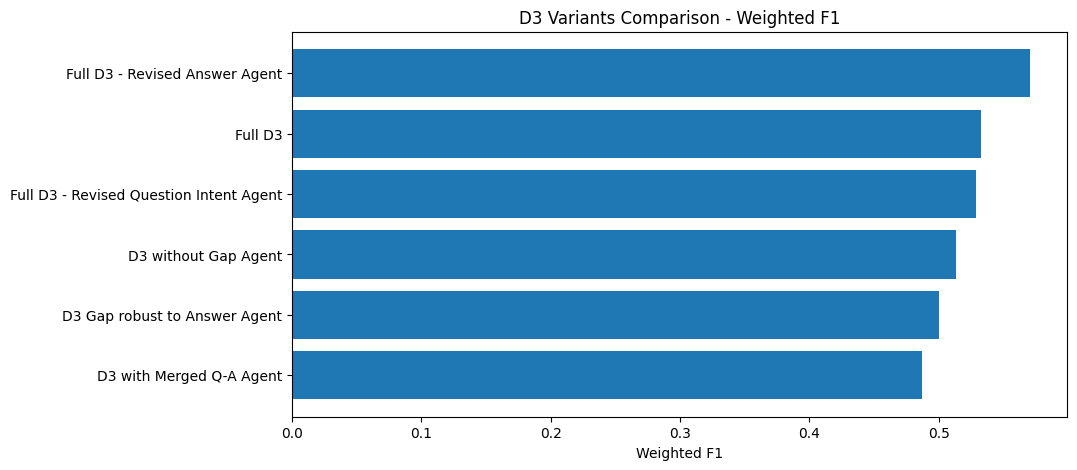

In [70]:
plt.figure(figsize=(10, 5))

scores_df_plot = scores_df.sort_values("f1_weighted", ascending=True)

plt.barh(scores_df_plot["model"], scores_df_plot["f1_weighted"])
plt.xlabel("Weighted F1")
plt.title("D3 Variants Comparison - Weighted F1")
plt.show()

In [71]:
import re

def diagnose_label(raw):
    obj = extract_json_object(str(raw))
    had_label = "label" in obj
    src = obj.get("label", raw)
    key = re.sub(r"\s+", " ", str(src).strip().lower().replace("_", " "))
    keys = ["clear non-reply","clear non reply","non-reply","non reply",
            "ambivalent","ambiguous","partial","unclear","clear reply"]
    matched = any(k in key for k in keys)
    return had_label, matched

for exp in experiments:
    df = exp["df"]
    if "d3_decision_raw" not in df.columns:
        print(f"{exp['name']:45s}  (no raw col)"); continue
    diag    = df["d3_decision_raw"].apply(diagnose_label)
    no_label = (~diag.apply(lambda t: t[0])).sum()   
    fellthru = (~diag.apply(lambda t: t[1])).sum()  
    n = len(df)
    print(f"{exp['name']:45s}  fallback→Ambivalent: {fellthru:4d}/{n} ({fellthru/n:4.1%})   no-label-field: {no_label}")

Full D3                                        fallback→Ambivalent:    0/300 (0.0%)   no-label-field: 4
D3 without Gap Agent                           fallback→Ambivalent:    0/300 (0.0%)   no-label-field: 2
D3 with Merged Q-A Agent                       fallback→Ambivalent:    0/300 (0.0%)   no-label-field: 7
Full D3 - Revised Question Intent Agent        fallback→Ambivalent:    0/300 (0.0%)   no-label-field: 3
Full D3 - Revised Answer Agent                 fallback→Ambivalent:    0/300 (0.0%)   no-label-field: 2
D3 Gap robust to Answer Agent                  fallback→Ambivalent:    0/300 (0.0%)   no-label-field: 3


In [72]:
def error_analysis(df, pred_col, true_col="clarity_label",
                   q_col="question", a_col="interview_answer",
                   labels=LABELS, n_examples=1):
    # Create a copy so the original results are not modified
    d = df.copy()

    # Mark each sample as correct/incorrect (gold vs predicted)
    d["correct"] = d[true_col] == d[pred_col]

    print("\n== Most common error pairs (true -> pred) ==")
    err = d[~d["correct"]]
    for (t, p), n in err.groupby([true_col, pred_col]).size().sort_values(ascending=False).items():
        print(f"  {t:16} -> {p:16}: {n}")

    # Answer / question length in words
    d["ans_len"] = d[a_col].astype(str).str.split().str.len()
    d["q_len"]   = d[q_col].astype(str).str.split().str.len()

    print("\n== Error rate by answer length ==")
    print((1 - d.groupby(pd.qcut(d["ans_len"], 4, duplicates="drop"), observed=True)["correct"].mean()).round(3))

    print("\n== Error rate by question length ==")
    print((1 - d.groupby(pd.qcut(d["q_len"], 4, duplicates="drop"), observed=True)["correct"].mean()).round(3))

    print("\n== Example error per class ==")
    # One example mistake per true class, for qualitative inspection
    for c in labels:
        for _, r in err[err[true_col] == c].head(n_examples).iterrows():
            print(f"\n[true={c} | pred={r[pred_col]}]")
            print("Q:", str(r[q_col])[:160])
            print("A:", str(r[a_col])[:240])

    return d


# Run the error analysis for every experiment/variant
for exp in experiments:
    print("\n" + "#"*90 + f"\n###  {exp['name']}\n" + "#"*90)
    error_analysis(exp["df"], pred_col=exp["pred_col"])


##########################################################################################
###  Full D3
##########################################################################################

== Most common error pairs (true -> pred) ==
  Clear Reply      -> Ambivalent      : 58
  Ambivalent       -> Clear Reply     : 42
  Clear Non-Reply  -> Ambivalent      : 25
  Ambivalent       -> Clear Non-Reply : 3
  Clear Non-Reply  -> Clear Reply     : 3
  Clear Reply      -> Clear Non-Reply : 1

== Error rate by answer length ==
ans_len
(0.999, 58.5]       0.427
(58.5, 197.5]       0.493
(197.5, 460.75]     0.427
(460.75, 1667.0]    0.413
Name: correct, dtype: float64

== Error rate by question length ==
q_len
(1.999, 8.0]    0.487
(8.0, 14.0]     0.400
(14.0, 19.0]    0.414
(19.0, 74.0]    0.458
Name: correct, dtype: float64

== Example error per class ==

[true=Clear Reply | pred=Ambivalent]
Q:  What gives the speaker confidence today to believe that the Prime Minister can achieve what 

# Second Set of Experiments: Few-Shot and DSPy-Based Improvements



In this set, the structure of the D3 pipeline is mostly preserved, but different enhancement strategies are applied. First, a kNN few-shot variant is tested, where semantically similar examples from the training set are retrieved and inserted into the prompt. The goal of this approach is to provide the model with relevant examples for each input instance and help it make more stable decisions.

In addition, several DSPy-based variants are evaluated. DSPy is used as a prompt optimization framework in order to improve selected components of the D3 pipeline without fine-tuning the underlying language model. Instead of updating model parameters, DSPy searches for better prompt instructions and/or examples for specific agents. In this work, the optimization focuses mainly on the Gap and Evasion Agent and the Decision Agent, since these components are directly involved in comparing the answer with the target question and assigning the final clarity label.

The evaluated variants in this second set are:

- **Full D3**, used as the reference baseline for this group of experiments.
- **D3 + kNN Few-Shot**, where similar labelled examples are dynamically retrieved and included in the prompt.
- **D3 + DSPy-Optimized Gap Agent**, where DSPy is used to improve the agent responsible for detecting missing information, partial coverage, and evasion.
- **D3 + DSPy-Optimized Decision Agent**, where DSPy optimizes the final classification component of the pipeline.
- **D3 + DSPy-MIPROv2 Decision**, where MIPROv2 is used to optimize the Decision Agent by searching over both instructions and demonstrations.

The purpose of this experimental set is to investigate whether the D3 pipeline can benefit from external examples or automatic prompt optimization, while still using the same fixed instruction-tuned language model.

## New Split

In [ ]:
from sklearn.model_selection import train_test_split

train_part, valid_df = train_test_split(
    df_train,
    test_size=100,                   
    random_state=42,
    stratify=df_train["clarity_label"]
)

train_part = train_part.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(train_part.shape, valid_df.shape)
print(valid_df["clarity_label"].value_counts())

(3290, 20) (100, 20)
clarity_label
Ambivalent         59
Clear Reply        31
Clear Non-Reply    10
Name: count, dtype: int64


## Baseline


In [ ]:

d3_full_val2 = run_d3_variant_dataframe_batched(
    df=valid_df,
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    question_col="question",
    answer_col="interview_answer",

    question_intent_prompt=QUESTION_INTENT_PROMPT,
    answer_content_prompt=ANSWER_CONTENT_PROMPT,
    gap_evasion_prompt=GAP_EVASION_PROMPT,
    decision_prompt=DECISION_PROMPT,
    
    use_question_intent=True,
    use_answer_content=True,
    use_gap_evasion=True,

    pred_col_name="pred_d3",
    variant_name="Full D3",

    limit=None,
    batch_size=8,

    max_tokens_question_intent=250,
    max_tokens_answer_content=450,
    max_tokens_gap_evasion=600,
    max_tokens_decision=200
)




Full D3 | Question Intent Agent:   0%|          | 0/38 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

experiments = [
    {
        "name": "Full D3",
        "df": d3_full_val2,
        "pred_col": "pred_d3"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

## Few shots knn  
### Experiment 7 


In this experiment, the original D3-Agentic pipeline is extended with a kNN-based few-shot prompting strategy. The motivation behind this approach is that the model may make more reliable predictions when it is shown examples that are similar to the current input, instead of reasoning only from the prompt instructions.

For each validation instance, the system first constructs a textual representation of the input using the target question and the interview answer. Then, this input is converted into a sentence embedding. The same embedding process is also applied to the training examples. Using these embeddings, the k-nearest neighbours of the current validation example are retrieved from the training set based on semantic similarity.

In this experiment, the kNN retrieval is used in an unbalanced setting, with `balanced=False`. This means that the nearest neighbours are selected only according to semantic similarity, without forcing the retrieved examples to be equally distributed across the three clarity labels. As a result, the selected demonstrations reflect the natural label distribution of the closest training examples.

The retrieved examples are then added to the prompt as few-shot demonstrations. Each demonstration includes a question, an answer, and the correct clarity label. In this way, the model receives examples of how similar cases were labelled before making its prediction for the current instance.

This method is different from using a fixed few-shot prompt, because the examples are selected dynamically for each input. Therefore, each validation sample receives a different set of demonstrations, depending on which training examples are most semantically similar to it.

The goal of this experiment is to test whether local, example-based guidance can improve the D3 pipeline, especially for difficult borderline cases where the difference between `Clear Reply` and `Ambivalent` is subtle. Since no model parameters are updated, this method remains a prompting-based approach and does not involve fine-tuning.


In [ ]:


# ============ PROMPT ============


DECISION_PROMPT_knn_fewshot = """
You are the Decision Agent for CLARITY response classification.
Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:
Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.
Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.
Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- If coverage is complete or mostly_complete and the answer resolves the target question -> Clear Reply.
- If coverage is partial/minimal but there is relevant information -> Ambivalent.
- If coverage is none, or the response is mainly refusal/deflection/irrelevant -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Below are retrieved examples that are semantically similar to the current case with their correct labels.
Use them ONLY as calibration for borderline decisions. Do not copy a label blindly;
first compare the current TARGET_QUESTION and ANSWER with the agent analyses, then decide.

Few-shot calibration examples:
{few_shot_examples}

Return exactly one JSON object and nothing else.
JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

In [ ]:

embedder = SentenceTransformer("all-MiniLM-L6-v2", device=str(device))

def make_text(q, a):
    """
    Creates the text representation that will be embedded.

    The question and answer are combined into a single text, because the
    similarity should be based on the full question-answer pair.
    The answer is truncated to avoid very long inputs.
    """
    return f"Question: {q}\nAnswer: {a}"



pool_texts  = [make_text(r['question'], r['interview_answer']) for _, r in train_part.iterrows()]
pool_emb    = embedder.encode(pool_texts, normalize_embeddings=True, show_progress_bar=True)


pool_labels = train_part['clarity_label'].tolist()
pool_q, pool_a = train_part['question'].tolist(), train_part['interview_answer'].tolist()

_pool_agent_cache = {}

def get_pool_agent_analysis(idx):

    if idx in _pool_agent_cache:
        return _pool_agent_cache[idx]

    q_ = str(pool_q[idx])
    a_ = str(pool_a[idx])

    qi_ = remove_raw(run_question_intent_agent(
        qwen_model, qwen_tokenizer, QUESTION_INTENT_PROMPT, q_, max_new_tokens=250))
    ac_ = remove_raw(run_answer_content_agent(
        qwen_model, qwen_tokenizer, ANSWER_CONTENT_PROMPT, q_, a_, max_new_tokens=450))
    ge_ = remove_raw(run_gap_evasion_agent(
        qwen_model, qwen_tokenizer, GAP_EVASION_PROMPT, q_, a_, qi_, ac_, max_new_tokens=450))

    _pool_agent_cache[idx] = (qi_, ac_, ge_)
    return qi_, ac_, ge_
    
def knn_examples(q, a, k=3, balanced=True, rich=False):
    qe   = embedder.encode([make_text(q, a)], normalize_embeddings=True)[0]
    sims = pool_emb @ qe
    order = np.argsort(-sims)
    if balanced:
        chosen, seen = [], set()
        for idx in order:
            if pool_labels[idx] not in seen:
                chosen.append(idx); seen.add(pool_labels[idx])
            if len(seen) == 3: break
        for idx in order:
            if len(chosen) >= k: break
            if idx not in chosen: chosen.append(idx)
        idxs = chosen[:k]
    else:
        idxs = order[:k]

    examples = []
    for i in idxs:
        i = int(i)
        ex = {"question": pool_q[i], "answer": pool_a[i], "label": pool_labels[i]}
        if rich:                                    # if i want to run agents 
            qi_, ac_, ge_ = get_pool_agent_analysis(i)
            ex.update(question_intent=qi_, answer_content=ac_, gap_evasion=ge_)
        examples.append(ex)
    return examples

def format_knn_examples_for_prompt(examples):
    if not examples:
        return "No examples provided."
    text = ""
    for i, ex in enumerate(examples, start=1):
        block = f"Example {i}\nQuestion:\n{ex['question']}\nAnswer:\n{str(ex['answer'])}\n"
        if "question_intent" in ex:                 # rich mode
            block += (f"Question Intent analysis:\n{json.dumps(ex['question_intent'], ensure_ascii=False)}\n"
                      f"Answer Content analysis:\n{json.dumps(ex['answer_content'], ensure_ascii=False)}\n"
                      f"Gap & Evasion analysis:\n{json.dumps(ex['gap_evasion'], ensure_ascii=False)}\n")
        block += f"Label:\n{ex['label']}"
        text += block.strip() + "\n\n" + "-" * 60 + "\n\n"
    return text.strip()


def build_dynamic_decision_prompt(base_decision_prompt, question, answer, k=3, balanced=False, rich=False):
    examples = knn_examples(q=question, a=answer, k=k, balanced=balanced, rich=rich)
    few_shot_examples = format_knn_examples_for_prompt(examples)
    dynamic_prompt = base_decision_prompt.replace("{few_shot_examples}", few_shot_examples)
    return dynamic_prompt, examples


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
q = valid_df["question"].iloc[0]
a = valid_df["interview_answer"].iloc[0]


dynamic_prompt, examples = build_dynamic_decision_prompt(
    base_decision_prompt=DECISION_PROMPT_knn_fewshot,
    question=q,
    answer=a,
    k=3,
    balanced=False,
)


print("\n=== PLACEHOLDER STILL THERE? ===", "{few_shot_examples}" in dynamic_prompt)
print("\n=== FULL DECISION PROMPT ===")
print(dynamic_prompt)


=== PLACEHOLDER STILL THERE? === False

=== FULL DECISION PROMPT ===
You are the Decision Agent for CLARITY response classification.
Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:
Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.
Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or relate

In [ ]:

def run_d3_knn(df, k=3, balanced=False, limit=None ):
    run_df = df.copy()
    if limit is not None:
        run_df = run_df.head(limit).copy()
    preds = []
    raws  = []                                          
    for _, r in tqdm(run_df.iterrows(), total=len(run_df), desc="D3 + KNN"):
        q = str(r["question"])
        a = str(r["interview_answer"])
        qi = remove_raw(run_question_intent_agent(qwen_model, qwen_tokenizer,
                        QUESTION_INTENT_PROMPT, q, max_new_tokens=250))
        ac = remove_raw(run_answer_content_agent(qwen_model, qwen_tokenizer,
                        ANSWER_CONTENT_PROMPT, q, a, max_new_tokens=450))
        ge = remove_raw(run_gap_evasion_agent(qwen_model, qwen_tokenizer,
                        GAP_EVASION_PROMPT, q, a, qi, ac, max_new_tokens=450))
        dyn_prompt, _ = build_dynamic_decision_prompt(DECISION_PROMPT_knn_fewshot, q, a,
                                                      k=k, balanced=balanced)
        dec = run_decision_agent(qwen_model, qwen_tokenizer, dyn_prompt,
                                 q, a, qi, ac, ge, max_new_tokens=150)
        preds.append(dec["label"])
        raws.append(dec["raw"])                        
    run_df = run_df.reset_index(drop=True)
    run_df["pred_d3_knn"] = preds
    run_df["d3_decision_raw"] = raws                    
    return run_df

In [ ]:


d3_knn_val = run_d3_knn(valid_df, k=3, balanced=False)



D3 + KNN:   0%|          | 0/100 [00:00<?, ?it/s]

D3 knn few shots
                 precision    recall  f1-score   support

    Clear Reply       0.34      0.32      0.33        31
     Ambivalent       0.58      0.66      0.62        59
Clear Non-Reply       0.50      0.20      0.29        10

       accuracy                           0.51       100
      macro avg       0.48      0.39      0.41       100
   weighted avg       0.50      0.51      0.50       100



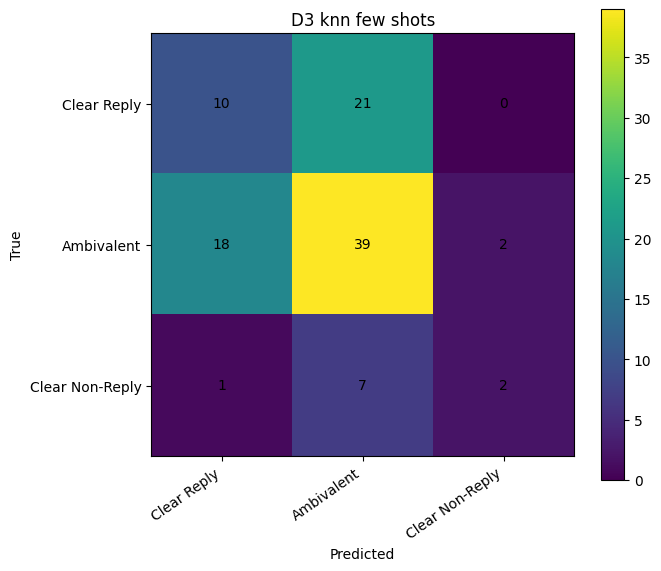

In [ ]:

experiments = [
    {
        "name": "D3 knn few shots",
        "df": d3_knn_val,
        "pred_col": "pred_d3_knn"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

## Prompt Optimization

DSPy allows the prompt behaviour of an agent to be optimized automatically, instead of relying only on manual prompt engineering. In this work, each optimized component is defined through a DSPy `Signature`, which specifies the input fields that the agent receives and the output fields that it is expected to produce. The signature is then wrapped inside a DSPy `Module`, so that the agent can be compiled and optimized with different DSPy optimizers.

The DSPy experiments focus on selected agents of the D3 pipeline, mainly the Gap and Evasion Agent and the Decision Agent. These agents were chosen because they play a central role in the final classification: the Gap and Evasion Agent evaluates whether the answer satisfies the target question, while the Decision Agent assigns the final clarity label.

We experimented with different optimization strategies. `BootstrapFewShot` was used to construct few-shot demonstrations automatically by running the program on training examples and keeping demonstrations that satisfy the evaluation metric. In addition, `MIPROv2` was tested as a more advanced optimizer, since it searches over both candidate instructions and few-shot demonstrations in order to improve the validation score. These optimization methods do not fine-tune the underlying language model; they only modify the prompt structure and the examples used by the agent.


In [ ]:


DECISION_PROMPT = """
You are the Decision Agent for CLARITY response classification.

Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:

Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.

Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.

Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- If coverage is complete or mostly_complete and the answer resolves the target question -> Clear Reply.
- If coverage is partial/minimal but there is relevant information -> Ambivalent.
- If coverage is none, or the response is mainly refusal/deflection/irrelevant -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Few-shot calibration examples:

Example A:
Target question: "Did you support the bill?"
Answer content: "Yes, I voted for it and I still support it."
Gap analysis: coverage complete; explicit answer.
Final label: Clear Reply.

Example B:
Target question: "What specific steps will you take to reduce prices?"
Answer content: "Families are struggling, this is important, and we are working every day."
Gap analysis: relevant but no specific steps.
Final label: Ambivalent.

Example C:
Target question: "Did you meet with the ambassador?"
Answer content: "I am not going to discuss private diplomatic conversations."
Gap analysis: declining to answer; no requested information.
Final label: Clear Non-Reply.

Example D:
Target question: "Why did unemployment increase?"
Answer content: "The economy has faced global pressure, energy shocks, and reduced demand."
Gap analysis: gives reasons even without saying 'because'.
Final label: Clear Reply.

Example E:
Target question: "Do you think President X is sincere?"
Answer content: "I am sincere about improving the relationship."
Gap analysis: answers the speaker's sincerity, not President X's sincerity.
Final label: Ambivalent.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

QUESTION_INTENT_PROMPT = """
You are the Question Intent Agent for a response-clarity classification task.

Important dataset rule:
The TARGET_QUESTION may be only one sub-question extracted from a longer interview question.
Analyze ONLY the TARGET_QUESTION. Do not require the answer to address other questions unless they are necessary for this target question.

Your task:
Identify exactly what information would make an answer clear for the TARGET_QUESTION.

Think in terms of answer requirements:
- Is the question asking for yes/no?
- Is it asking what happened?
- Is it asking why/how something happened?
- Is it asking for a specific action, plan, reason, explanation, stance, or evaluation?
- Is it asking about a named person, event, country, policy, organization, or date?

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_type": "yes_no|what|why|how|when|where|who|stance|explanation|action_plan|evaluation|other",
  "question_intent": "one sentence describing what the target question asks",
  "must_address": [
    "specific requirement 1",
    "specific requirement 2"
  ],
  "clear_answer_criteria": "one sentence describing what a clear answer must contain",
  "minimal_sufficient_answer": "short description of the minimum information needed for Clear Reply"
}
""".strip()

ANSWER_CONTENT_PROMPT = """
You are the Answer Content Agent for a response-clarity classification task.

Important dataset rule:
The answer may respond to a longer interview question, but you must evaluate what it says with respect to the TARGET_QUESTION only.

Your task:
Extract what the answer actually says that is relevant to the TARGET_QUESTION.

Do not decide the final label.
Do not reward political rhetoric unless it answers the target question.
Do not infer facts that are not present in the answer.
An implicit answer is allowed only if the answer gives enough information to resolve the target question.

Look for:
direct answer phrases: yes, no, I did, I did not, we will, we will not, because...
concrete facts, actions, reasons, explanations, examples, commitments
vague but related statements
topic shifts
refusals or declines to answer
answers to a different sub-question

Return exactly one JSON object and nothing else.

JSON schema:
{
  "relevant_answer_summary": "one sentence summarizing only content relevant to the target question",
  "direct_answer_present": true,
  "direct_answer_text": "exact short phrase if present, otherwise empty string",
  "concrete_information": [
    "concrete relevant point 1",
    "concrete relevant point 2"
  ],
  "vague_or_general_information": [
    "vague/general relevant point 1"
  ],
  "off_target_content": [
    "content that answers a different question or changes topic"
  ],
  "refusal_or_non_answer_signals": [
    "signal 1"
  ]
}
""".strip()


GAP_EVASION_PROMPT = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. the Question Intent Agent output,
4. the Answer Content Agent output.

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "missing requirement 1"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()


In [ ]:
class AttrDict(dict):
    """
    Dictionary with attribute access.
    Supports both response["choices"] and response.choices.
    """
    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = value


class KaggleQwenDSPyLM(dspy.BaseLM):
    # Wraps the local Qwen model so DSPy can call it like any LM provider.
    def __init__(self, model, tokenizer, model_name="local-qwen3.5-0.8b"):
        # Pass generation defaults up to BaseLM; cache=False to avoid stale replays.
        super().__init__(
            model=model_name,
            model_type="chat",
            cache=False,
            temperature=0.0,
            max_tokens=400,
        )
        self.local_model = model
        self.local_tokenizer = tokenizer
        self.model_name = model_name

    def forward(self, prompt=None, messages=None, **kwargs):
        """Called by DSPy for every LM request; routes it to local generate_chat."""
        # DSPy may pass either a raw prompt or a messages list — normalize to messages.
        if messages is None:
            messages = [{"role": "user", "content": prompt or ""}]

        # Accept either DSPy's max_tokens or HF's max_new_tokens.
        max_new_tokens = kwargs.get("max_tokens", kwargs.get("max_new_tokens", 400))

        text = generate_chat(
            model=self.local_model,
            tokenizer=self.local_tokenizer,
            messages=messages,
            max_new_tokens=max_new_tokens,
        )

        # Mimic the OpenAI chat.completion shape so DSPy's parser can read it.
        return AttrDict({
            "id": f"chatcmpl-local-{int(time.time() * 1000)}",
            "object": "chat.completion",
            "created": int(time.time()),
            "model": self.model_name,
            "choices": [
                AttrDict({
                    "index": 0,
                    "message": AttrDict({"role": "assistant", "content": text}),
                    "text": text,  # some DSPy adapters read .text instead of .message
                    "finish_reason": "stop",
                })
            ],
            # Usage is zeroed — we don't track token counts locally.
            "usage": AttrDict({
                "prompt_tokens": 0,
                "completion_tokens": 0,
                "total_tokens": 0,
            }),
        })


# Build the DSPy-compatible LM from the local Qwen model and set it as the default.
dspy_lm = KaggleQwenDSPyLM(
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    model_name="local-qwen3.5-0.8b",
)
# dspy.configure(lm=dspy_lm, adapter=dspy.ChatAdapter())  # explicit adapter, if needed
dspy.configure(lm=dspy_lm)

###  Experiment 8 Dspy Gap/Evasion Agent


The ablation experiments showed that the Gap and Evasion Agent plays an important role in the D3 pipeline. Removing this component caused the largest drop in macro-F1, which suggests that the explicit comparison between the target question and the answer is useful for the final prediction. For this reason, we tested whether this agent could be improved automatically with DSPy.

In this experiment, only the Gap and Evasion Agent is replaced with a DSPy-based version, while the rest of the pipeline remains unchanged. The goal is to isolate the effect of optimizing the gap-detection step and evaluate whether better intermediate gap analysis can improve the final clarity classification.

The optimized Gap and Evasion component consists of the following parts:

* `GapEvasionSignature`: defines the inputs and outputs of the agent. It receives the target sub-question, the interview answer, and the outputs of the Question Intent and Answer Content Agents. It produces the gap-related fields, such as `coverage`, `gap_level`, `best_evasion_category`, `missing_requirements`, and `gap_explanation`. The final clarity label is not produced by this agent, but remains the responsibility of the Decision Agent.

* `DSPyGapEvasionAgent`: wraps the signature in a DSPy `Module` using `dspy.Predict`, so that the agent can be compiled and optimized by DSPy.

* `dspy_gap_prediction_to_dict` and `parse_semicolon_or_lines`: convert the DSPy output back into the same dictionary format used by the original manually prompted Gap and Evasion Agent. This allows the downstream Decision Agent to receive the optimized gap output in the same format as before. The `missing_requirements` field is also normalized into a clean list of at most five items.

The optimization uses a downstream metric. Instead of scoring the gap output directly, `gap_downstream_metric` passes the optimized gap prediction to the unchanged Decision Agent and gives a positive score only when the final predicted label matches the gold label. In this way, the Gap and Evasion Agent is optimized based on how much it helps the final classification, rather than only on the form of its intermediate output.


In [ ]:
def parse_semicolon_or_lines(x):
    # Turn free-text (semicolons / newlines / "- " bullets) into a clean list, capped at 5.
    if x is None:
        return []
    s = str(x).strip()
    if not s:
        return []
    parts = re.split(r";|\n|(?:^|\s)-\s+", s)
    parts = [p.strip(" -•\t") for p in parts if p.strip(" -•\t")]
    return parts[:5]


def dspy_gap_prediction_to_dict(pred):
    """Convert DSPy's Gap prediction into the dict format the original Gap agent used."""
    # getattr with defaults so a malformed prediction never breaks the pipeline.
    return {
        "coverage": str(getattr(pred, "coverage", "partial")).strip(),
        "gap_level": str(getattr(pred, "gap_level", "partial")).strip(),
        "best_evasion_category": str(getattr(pred, "best_evasion_category", "general_answer")).strip(),
        "missing_requirements": parse_semicolon_or_lines(getattr(pred, "missing_requirements", "")),
        "gap_explanation": str(getattr(pred, "gap_explanation", "")).strip(),
        "raw": str(pred),
        "source": "dspy_optimized_gap_evasion",
    }


class GapEvasionSignature(dspy.Signature):
    """
    Compare what the TARGET_QUESTION requires with what the answer provides,
    and detect missing parts, partial answers, or evasion.
    Do not assign the final clarity label.
    """
    # Inputs: the sub-question + answer + the two upstream agents' outputs.
    target_question = dspy.InputField(desc="The specific target sub-question to analyze.")
    answer          = dspy.InputField(desc="The politician's answer.")
    question_intent = dspy.InputField(desc="Question Intent output: what a clear answer must provide.")
    answer_content  = dspy.InputField(desc="Answer Content output: what the answer actually says.")
    # Outputs: gap signals only — never the final label.
    coverage              = dspy.OutputField(desc="One of: complete, mostly_complete, partial, minimal, none.")
    gap_level             = dspy.OutputField(desc="One of: none, minor, partial, major.")
    best_evasion_category = dspy.OutputField(desc="One of: explicit_answer, implicit_answer, partial_half_answer, general_answer, dodging, deflection, declining_to_answer, claims_ignorance, clarification_only, irrelevant.")
    missing_requirements  = dspy.OutputField(desc="A semicolon-separated list of requirements the answer fails to provide.")
    gap_explanation       = dspy.OutputField(desc="One sentence explaining the main gap or why the answer is clear.")


class DSPyGapEvasionAgent(dspy.Module):
    def __init__(self):
        super().__init__()
        # dspy.Predict makes the signature optimizable (instructions + demos).
        self.predict = dspy.Predict(GapEvasionSignature)

    def forward(self, target_question, answer, question_intent, answer_content, label=None):
        ge = self.predict(
            target_question=target_question,
            answer=answer,
            question_intent=question_intent,
            answer_content=answer_content,
        )
        # Re-wrap as a Prediction with safe defaults.
        return dspy.Prediction(
            coverage=getattr(ge, "coverage", "partial"),
            gap_level=getattr(ge, "gap_level", "partial"),
            best_evasion_category=getattr(ge, "best_evasion_category", "general_answer"),
            missing_requirements=getattr(ge, "missing_requirements", ""),
            gap_explanation=getattr(ge, "gap_explanation", ""),
        )


def run_d3_with_dspy_gap_program(example, gap_program):
    # Full D3 path at inference: DSPy gap program -> dict -> Decision agent.
    q = example.target_question
    a = example.answer

    gp = gap_program(
        target_question=q,
        answer=a,
        question_intent=example.question_intent,
        answer_content=example.answer_content,
    )
    gap_evasion = dspy_gap_prediction_to_dict(gp)

    decision = run_decision_agent(
        qwen_model, qwen_tokenizer, DECISION_PROMPT, q, a,
        example.question_intent, example.answer_content, gap_evasion, max_new_tokens=150)

    return decision["label"], decision["raw"]


def gap_downstream_metric(example, pred, trace=None):
    # Optimizer metric: score the gap output by the FINAL label it leads to.
    gap_evasion = dspy_gap_prediction_to_dict(pred)
    q = example.target_question
    a = example.answer

    decision = run_decision_agent(
        qwen_model, qwen_tokenizer, DECISION_PROMPT, q, a,
        example.question_intent, example.answer_content, gap_evasion, max_new_tokens=150)

    predicted_label = normalize_prediction_label(decision["label"])
    gold_label = normalize_prediction_label(example.label)
    return 1.0 if predicted_label == gold_label else 0.0  # 1 if final label matches gold

### Building the Training Set and Optimizing the Gap Agent with BootstrapFewShot

This block prepares the data used to optimize the Gap and Evasion Agent, runs the `BootstrapFewShot` optimizer, and then evaluates the optimized agent on the validation set.

First, the function `build_gap_dspy_examples` constructs a small balanced training set for DSPy. For each clarity label, a fixed number of examples is sampled using a fixed random seed, so that the same examples are selected every time the notebook is run. Keeping the same number of examples per class helps prevent the optimizer from being guided mainly by the majority class.

For each sampled row, the two upstream agents, Question Intent and Answer Content, are executed once. Their outputs are stored inside the corresponding `dspy.Example`, together with the original target question, answer, and gold label. This precomputed context ensures that the optimization focuses only on the Gap and Evasion Agent, while the previous stages of the pipeline remain fixed. The `.with_inputs(...)` call tells DSPy which fields should be treated as inputs; the gold `label` is therefore kept only for scoring and is not given as an input to the optimized agent.

The optimization is performed with `BootstrapFewShot` and the downstream metric defined earlier. In this setup, `max_bootstrapped_demos=4` allows the optimizer to keep up to four successful bootstrapped demonstrations, while `max_labeled_demos=0` means that no raw labelled examples are inserted directly as demonstrations. Instead, only generated traces that pass the metric are used. The `max_errors=30` parameter allows the optimization process to continue even if some generations fail.

Finally, the optimized Gap and Evasion Agent is evaluated with `run_d3_dspy_gap`. For each validation example, the upstream Question Intent and Answer Content outputs are rebuilt in the same way as during optimization. The optimized Gap Agent then produces the gap analysis, which is passed to the unchanged Decision Agent. The final predicted label and the raw decision output are saved in new columns for evaluation.


In [ ]:
DSPY_GAP_EXAMPLES_PER_CLASS = 4
DSPY_GAP_RANDOM_SEED = 42


def build_gap_dspy_examples(df, per_class=4):
    # Build a class-balanced, reproducible trainset for optimizing Agent 3.
    examples = []
    for label in LABELS:
        subset = df[df["clarity_label"] == label].copy()
        if len(subset) == 0:
            continue
        # Sample up to per_class rows of this label (fixed seed -> reproducible).
        subset = subset.sample(n=min(per_class, len(subset)), random_state=DSPY_GAP_RANDOM_SEED)
        for _, row in subset.iterrows():
            q = str(row["question"]); a = str(row["interview_answer"])
            # Pre-compute the upstream agents so the optimizer only varies the gap agent.
            qi = remove_raw(run_question_intent_agent(
                qwen_model, qwen_tokenizer, QUESTION_INTENT_PROMPT, q, max_new_tokens=250))
            ac = remove_raw(run_answer_content_agent(
                qwen_model, qwen_tokenizer, ANSWER_CONTENT_PROMPT, q, a, max_new_tokens=450))
            examples.append(
                dspy.Example(
                    target_question=q,
                    answer=a,
                    question_intent=qi,
                    answer_content=ac,
                    label=str(row["clarity_label"]),
                ).with_inputs("target_question", "answer", "question_intent", "answer_content")  # label stays held-out
            )
    # Shuffle deterministically so label order doesn't bias bootstrapping.
    random.Random(DSPY_GAP_RANDOM_SEED).shuffle(examples)
    return examples


dspy_gap_trainset = build_gap_dspy_examples(train_part, per_class=DSPY_GAP_EXAMPLES_PER_CLASS)
print("DSPy Gap & Evasion optimization examples:", len(dspy_gap_trainset))

base_gap_program = DSPyGapEvasionAgent()  # unoptimized starting point
gap_optimizer = dspy.BootstrapFewShot(
    metric=gap_downstream_metric,   # score by final label, not gap output
    max_bootstrapped_demos=4,       # at most 4 self-generated demos
    max_labeled_demos=0,            # no raw labeled examples injected
    max_rounds=1,
    max_errors=30,                  # tolerate failed generations
)
optimized_gap_program = gap_optimizer.compile(base_gap_program, trainset=dspy_gap_trainset)
print("Finished DSPy optimization for the Gap & Evasion Agent.")


def run_d3_dspy_gap(df, gap_program):
    # Run the full D3 pipeline with the optimized gap program over a dataframe.
    run_df = df.copy().reset_index(drop=True)
    preds = []
    raws  = []
    for _, r in tqdm(run_df.iterrows(), total=len(run_df), desc="D3 + DSPy-Gap"):
        q = str(r["question"]); a = str(r["interview_answer"])
        # Recompute upstream agents exactly as during training -> consistent inputs.
        qi = remove_raw(run_question_intent_agent(
            qwen_model, qwen_tokenizer, QUESTION_INTENT_PROMPT, q, max_new_tokens=250))
        ac = remove_raw(run_answer_content_agent(
            qwen_model, qwen_tokenizer, ANSWER_CONTENT_PROMPT, q, a, max_new_tokens=450))
        ex = dspy.Example(
            target_question=q, answer=a, question_intent=qi, answer_content=ac
        ).with_inputs("target_question", "answer", "question_intent", "answer_content")
        lab, raw = run_d3_with_dspy_gap_program(ex, gap_program)
        preds.append(lab); raws.append(raw)
    run_df["pred_d3_dspy_gap"] = preds
    run_df["d3_decision_raw"]  = raws
    return run_df


d3_dspy_gap_val = run_d3_dspy_gap(valid_df, optimized_gap_program)

DSPy Gap & Evasion optimization examples: 12


100%|██████████| 12/12 [03:21<00:00, 16.83s/it]

Bootstrapped 3 full traces after 11 examples for up to 1 rounds, amounting to 12 attempts.
Finished DSPy optimization for the Gap & Evasion Agent.


D3 + DSPy-Gap:   0%|          | 0/100 [00:00<?, ?it/s]

D3 with Dspy Gap Agent BootstrapFewShot
                 precision    recall  f1-score   support

    Clear Reply       0.35      0.48      0.41        31
     Ambivalent       0.60      0.58      0.59        59
Clear Non-Reply       0.00      0.00      0.00        10

       accuracy                           0.49       100
      macro avg       0.32      0.35      0.33       100
   weighted avg       0.46      0.49      0.47       100



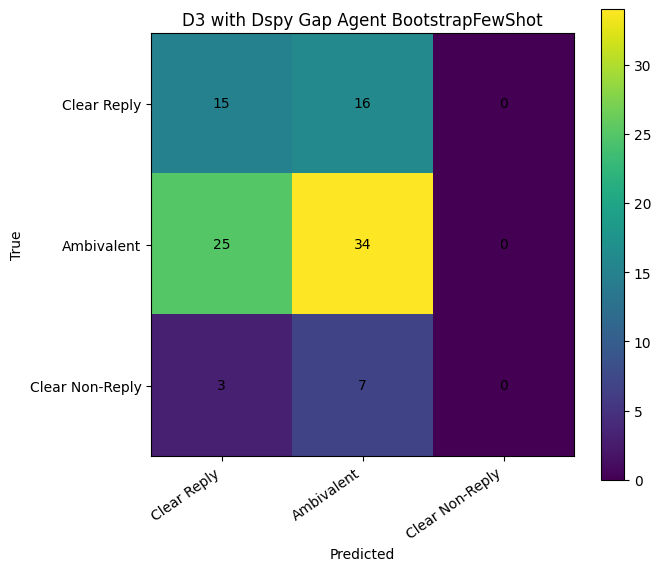

In [ ]:

experiments = [
    {
        "name": "D3 with Dspy Gap Agent BootstrapFewShot",
        "df": d3_dspy_gap_val,
        "pred_col": "pred_d3_dspy_gap"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

### Experiment 9 Dspy Decision Agent


This block defines the DSPy version of the final Decision Agent and the metric used to evaluate it. The same `Signature`, `Module`, and metric are reused for the Decision Agent optimization experiments with BootstrapFewShot and MIPROv2; only the optimizer changes.

The Decision Agent is different from the Gap and Evasion Agent because it is the final stage of the D3 pipeline. Its output is the final clarity label, so there is no downstream agent that needs to interpret its result. For this reason, the Decision Agent can be evaluated directly by comparing its predicted label with the gold label.

The `DecisionSignature` defines the inputs and outputs of the agent. It receives the target question, the interview answer, and the outputs of the three previous agents: Question Intent, Answer Content, and Gap and Evasion. It then produces the final `label` and a short `rationale`. The signature restricts the output to the three valid classes: `Clear Reply`, `Ambivalent`, and `Clear Non-Reply`.

The `DSPyDecisionAgent` wraps this signature in a DSPy `Module` using `dspy.Predict`. It returns a DSPy prediction containing the final label and rationale, with safe default values in case one of the fields is missing.

The helper function `run_d3_with_dspy_decision_program` runs the optimized Decision Agent on a single example. It stores the predicted label and rationale in JSON format for logging and returns the normalized predicted label. Since this is the final agent of the pipeline, no additional agent is called after it.

Finally, `decision_metric` is used to evaluate the optimized Decision Agent. It applies `normalize_prediction_label` to map small output variations to the canonical class names, and then computes an exact-match score. The metric returns `1.0` when the predicted label matches the gold label and `0.0` otherwise.


In [ ]:
class DecisionSignature(dspy.Signature):
    """
    Assign the final response-clarity label using the question, answer, and the three agent outputs.
    Output exactly one of: Clear Reply, Ambivalent, Clear Non-Reply. Do not invent new labels.
    """
    # Inputs: the raw pair + all three upstream agent outputs.
    question        = dspy.InputField(desc="The target question.")
    answer          = dspy.InputField(desc="The interview answer.")
    question_intent = dspy.InputField(desc="Question Intent agent output.")
    answer_content  = dspy.InputField(desc="Answer Content agent output.")
    gap_evasion     = dspy.InputField(desc="Gap and Evasion agent output.")
    # Outputs: the final label (closed set) + a one-line justification.
    label     = dspy.OutputField(desc="One of: Clear Reply, Ambivalent, Clear Non-Reply.")
    rationale = dspy.OutputField(desc="One short sentence justifying the label.")


class DSPyDecisionAgent(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predict = dspy.Predict(DecisionSignature)  # optimizable predictor

    def forward(self, question, answer, question_intent, answer_content, gap_evasion, label=None):
        out = self.predict(
            question=question,
            answer=answer,
            question_intent=question_intent,
            answer_content=answer_content,
            gap_evasion=gap_evasion,
        )
        # Re-wrap with safe defaults.
        return dspy.Prediction(
            label=getattr(out, "label", ""),
            rationale=getattr(out, "rationale", ""),
        )


def run_d3_with_dspy_decision_program(example, decision_program):
    # Decision is the final stage -> its output is the prediction (no chaining).
    out = decision_program(
        question=example.question,
        answer=example.answer,
        question_intent=example.question_intent,
        answer_content=example.answer_content,
        gap_evasion=example.gap_evasion,
    )
    # Serialize label + rationale for logging/inspection.
    raw = json.dumps({
        "label":     str(getattr(out, "label", "")),
        "rationale": str(getattr(out, "rationale", "")),
    }, ensure_ascii=False)
    return normalize_prediction_label(getattr(out, "label", "")), raw


def decision_metric(example, pred, trace=None):
    # Direct exact-match on normalized labels (Decision output is the final answer).
    predicted_label = normalize_prediction_label(getattr(pred, "label", ""))
    gold_label = normalize_prediction_label(example.label)
    return 1.0 if predicted_label == gold_label else 0.0

In [ ]:
DSPY_DEC_EXAMPLES_PER_CLASS = 4
DSPY_DEC_RANDOM_SEED = 42


def build_decision_dspy_examples(df, per_class=4):
    # Class-balanced, seeded trainset for the final Decision agent.
    examples = []
    for label in LABELS:
        subset = df[df["clarity_label"] == label].copy()
        if len(subset) == 0:
            continue
        subset = subset.sample(n=min(per_class, len(subset)), random_state=DSPY_DEC_RANDOM_SEED)
        for _, row in subset.iterrows():
            q = str(row["question"]); a = str(row["interview_answer"])
            # All 3 upstream agents (Decision consumes their outputs).
            qi = remove_raw(run_question_intent_agent(
                qwen_model, qwen_tokenizer, QUESTION_INTENT_PROMPT, q, max_new_tokens=250))
            ac = remove_raw(run_answer_content_agent(
                qwen_model, qwen_tokenizer, ANSWER_CONTENT_PROMPT, q, a, max_new_tokens=450))
            ge = remove_raw(run_gap_evasion_agent(
                qwen_model, qwen_tokenizer, GAP_EVASION_PROMPT, q, a, qi, ac, max_new_tokens=450))
            examples.append(
                dspy.Example(
                    question=q,
                    answer=a,
                    question_intent=qi,
                    answer_content=ac,
                    gap_evasion=ge,
                    label=str(row["clarity_label"]),
                ).with_inputs("question", "answer", "question_intent", "answer_content", "gap_evasion")  # label held out
            )
    random.Random(DSPY_DEC_RANDOM_SEED).shuffle(examples)  # deterministic shuffle
    return examples


dspy_dec_trainset = build_decision_dspy_examples(train_part, per_class=DSPY_DEC_EXAMPLES_PER_CLASS)
print("DSPy Decision optimization examples:", len(dspy_dec_trainset))

base_decision_program = DSPyDecisionAgent()  # unoptimized starting point
decision_optimizer = dspy.BootstrapFewShot(
    metric=decision_metric,     # direct: Decision's output IS the final label
    max_bootstrapped_demos=4,
    max_labeled_demos=0,        # no raw labeled examples injected
    max_rounds=1,
    max_errors=30,
)
optimized_decision_program = decision_optimizer.compile(base_decision_program, trainset=dspy_dec_trainset)
print("Finished DSPy optimization for the Decision Agent.")


def run_d3_dspy_decision(df, decision_program):
    # Full D3 pipeline using the optimized Decision agent.
    run_df = df.copy().reset_index(drop=True)
    preds = []
    raws  = []
    for _, r in tqdm(run_df.iterrows(), total=len(run_df), desc="D3 + DSPy-Decision"):
        q = str(r["question"]); a = str(r["interview_answer"])
        # Recompute the full upstream chain (3 agents) to match training.
        qi = remove_raw(run_question_intent_agent(
            qwen_model, qwen_tokenizer, QUESTION_INTENT_PROMPT, q, max_new_tokens=250))
        ac = remove_raw(run_answer_content_agent(
            qwen_model, qwen_tokenizer, ANSWER_CONTENT_PROMPT, q, a, max_new_tokens=450))
        ge = remove_raw(run_gap_evasion_agent(
            qwen_model, qwen_tokenizer, GAP_EVASION_PROMPT, q, a, qi, ac, max_new_tokens=450))
        ex = dspy.Example(
            question=q, answer=a, question_intent=qi, answer_content=ac, gap_evasion=ge
        ).with_inputs("question", "answer", "question_intent", "answer_content", "gap_evasion")
        lab, raw = run_d3_with_dspy_decision_program(ex, decision_program)
        preds.append(lab); raws.append(raw)
    run_df["pred_d3_dspy_dec"] = preds
    run_df["d3_decision_raw"]  = raws
    return run_df


d3_dspy_decB_val = run_d3_dspy_decision(valid_df, optimized_decision_program)

DSPy Decision optimization examples: 12


 58%|█████▊    | 7/12 [00:30<00:21,  4.34s/it]

Bootstrapped 4 full traces after 7 examples for up to 1 rounds, amounting to 7 attempts.
Finished DSPy optimization for the Decision Agent.


D3 + DSPy-Decision:   0%|          | 0/100 [00:00<?, ?it/s]

D3 with Dspy Decision Agent BootstrapFewShot
                 precision    recall  f1-score   support

    Clear Reply       0.39      0.55      0.45        31
     Ambivalent       0.50      0.03      0.06        59
Clear Non-Reply       0.17      0.90      0.29        10

       accuracy                           0.28       100
      macro avg       0.35      0.49      0.27       100
   weighted avg       0.43      0.28      0.21       100



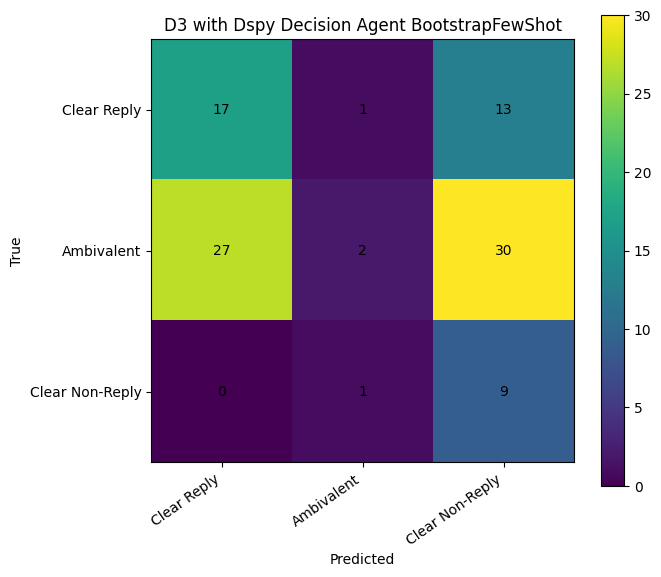

In [ ]:

experiments = [
    {
        "name": "D3 with Dspy Decision Agent BootstrapFewShot",
        "df": d3_dspy_decB_val,
        "pred_col": "pred_d3_dspy_dec"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

### Experiment 10 MIPROv2


This experiment applies MIPROv2 to the Decision Agent. MIPROv2 is a more advanced DSPy optimizer than BootstrapFewShot, because it does not only select few-shot demonstrations. It also searches over alternative instructions for the agent and tries to find the combination of instructions and examples that gives the best validation score.

In this setup, MIPROv2 uses two model roles: a `prompt_model`, which proposes candidate instructions, and a `task_model`, which runs the actual classification task. In our implementation, both roles are assigned to the same local Qwen model.

The parameter `auto="light"` is used to keep the optimization relatively small and computationally feasible. This is important because the experiments are run in a limited Kaggle environment. The optimizer is also allowed to use both bootstrapped demonstrations and a small number of labelled examples, which makes it different from the previous BootstrapFewShot setup.

The goal of this experiment is to test whether optimizing both the Decision Agent instructions and its demonstrations can improve the final clarity classification compared with the manually written Decision Agent and the simpler BootstrapFewShot optimization.

In [ ]:
from dspy.teleprompt import MIPROv2

mipro = MIPROv2(
    metric=decision_metric,
    auto="light",          # search size: light/medium/heavy — light = few trials, fast
    prompt_model=dspy_lm,  # proposes the new instructions (here the local Qwen)
    task_model=dspy_lm,    # runs the task
    num_threads=1,         # KEEP at 1: the local HF Qwen is not thread-safe
)

optimized_decision_mipro = mipro.compile(
    DSPyDecisionAgent(),
    trainset=dspy_dec_trainset,        # reuse the same trainset
    max_bootstrapped_demos=3,          # self-generated demos
    max_labeled_demos=2,               # + a few raw labeled (unlike the BootstrapFewShot run)
    requires_permission_to_run=False,  
)
print("Finished MIPROv2 optimization for the Decision Agent.")

# Same evaluation function as the previous runs.
d3_dspy_dec_mipro_val = run_d3_dspy_decision(valid_df, optimized_decision_mipro)

2026/06/12 19:04:15 WARNING dspy.teleprompt.mipro_optimizer_v2: 'requires_permission_to_run' is deprecated and will be removed in a future version.
2026/06/12 19:04:15 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING LIGHT AUTO RUN SETTINGS:
num_trials: 10
minibatch: False
num_fewshot_candidates: 6
num_instruct_candidates: 3
valset size: 9

2026/06/12 19:04:15 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/06/12 19:04:15 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/06/12 19:04:15 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=6 sets of demonstrations...


Bootstrapping set 1/6
Bootstrapping set 2/6
Bootstrapping set 3/6


100%|██████████| 3/3 [00:08<00:00,  2.96s/it]


Bootstrapped 0 full traces after 2 examples for up to 1 rounds, amounting to 3 attempts.
Bootstrapping set 4/6


100%|██████████| 3/3 [00:09<00:00,  3.01s/it]


...

2026/06/12 19:15:07 INFO dspy.evaluate.evaluate: Average Metric: 5.0 / 9 (55.6%)
2026/06/12 19:15:07 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 55.56 with parameters ['Predictor 0: Instruction 2', 'Predictor 0: Few-Shot Set 5'].
2026/06/12 19:15:07 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [55.56, 22.22, 55.56, 55.56, 66.67, 55.56, 55.56, 55.56, 22.22, 55.56]
2026/06/12 19:15:07 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 66.67
2026/06/12 19:15:07 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/06/12 19:15:07 INFO dspy.teleprompt.mipro_optimizer_v2: ===== Trial 11 / 10 =====



Average Metric: 6.00 / 9 (66.7%): 100%|██████████| 9/9 [00:28<00:00,  3.12s/it] 

2026/06/12 19:15:35 INFO dspy.evaluate.evaluate: Average Metric: 6.0 / 9 (66.7%)
2026/06/12 19:15:35 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 66.67 with parameters ['Predictor 0: Instruction 2', 'Predictor 0: Few-Shot Set 2'].
2026/06/12 19:15:35 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [55.56, 22.22, 55.56, 55.56, 66.67, 55.56, 55.56, 55.56, 22.22, 55.56, 66.67]
2026/06/12 19:15:35 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 66.67
2026/06/12 19:15:35 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2026/06/12 19:15:35 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 66.67!



Finished MIPROv2 optimization for the Decision Agent.


D3 + DSPy-Decision:   0%|          | 0/100 [00:00<?, ?it/s]

D3 with Dspy Decision Agent MIPROv2
                 precision    recall  f1-score   support

    Clear Reply       0.34      0.61      0.44        31
     Ambivalent       0.54      0.37      0.44        59
Clear Non-Reply       0.33      0.10      0.15        10

       accuracy                           0.42       100
      macro avg       0.40      0.36      0.34       100
   weighted avg       0.46      0.42      0.41       100



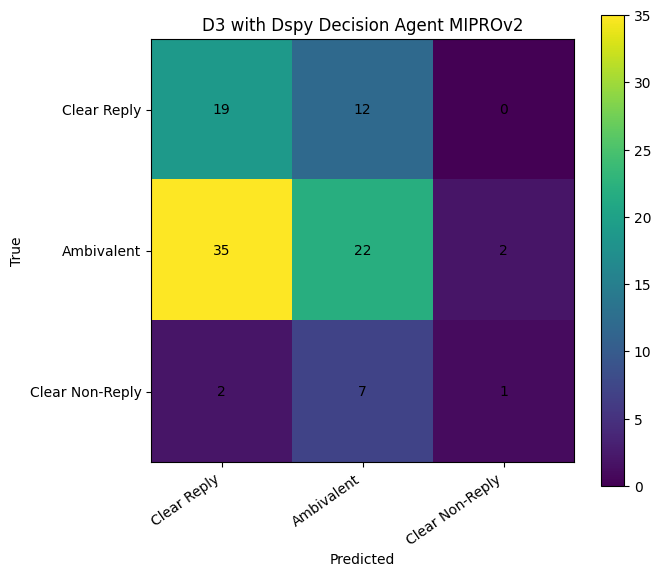

In [ ]:

experiments = [
    {
        "name": "D3 with Dspy Decision Agent MIPROv2",
        "df": d3_dspy_dec_mipro_val,
        "pred_col": "pred_d3_dspy_dec"
    },

]

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    print_full_report(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )
    plot_confusion_matrix(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        title=name,
        labels=LABELS
    )

# Second  Evaluation

In [ ]:
LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

experiments = [
    {"name": "Full D3",                              "df": d3_full_val2,                "pred_col": "pred_d3"},
    {"name": "D3 + KNN Few-Shot",                    "df": d3_knn_val,                 "pred_col": "pred_d3_knn"},
    {"name": "D3 + DSPy-Optimized Gap Agent",        "df": d3_dspy_gap_val,            "pred_col": "pred_d3_dspy_gap"},
    {"name": "D3 + DSPy-Optimized Decision Agent",   "df": d3_dspy_decB_val,           "pred_col": "pred_d3_dspy_dec"},
    {"name": "D3 + DSPy-MIPROv2 Decision",           "df": d3_dspy_dec_mipro_val,      "pred_col": "pred_d3_dspy_dec"},
]

In [ ]:
all_scores = []

for exp in experiments:
    name = exp["name"]
    df_exp = exp["df"]
    pred_col = exp["pred_col"]

    scores = evaluate_predictions(
        y_true=df_exp["clarity_label"],
        y_pred=df_exp[pred_col],
        model_name=name,
        labels=LABELS
    )
    all_scores.append(scores)


scores_df = pd.DataFrame(all_scores)

scores_df = scores_df.sort_values(
    "f1_weighted",
    ascending=False
).reset_index(drop=True)

scores_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,D3 + KNN Few-Shot,0.51,0.475639,0.394533,0.412698,0.500329,0.51,0.497143
1,Full D3,0.52,0.309078,0.339712,0.320802,0.450146,0.52,0.479398
2,D3 + DSPy-Optimized Gap Agent,0.49,0.315109,0.353381,0.330537,0.460069,0.49,0.471538
3,D3 + DSPy-MIPROv2 Decision,0.42,0.403068,0.361928,0.343543,0.455097,0.42,0.410387
4,D3 + DSPy-Optimized Decision Agent,0.28,0.353147,0.494095,0.269049,0.432080,0.28,0.207026


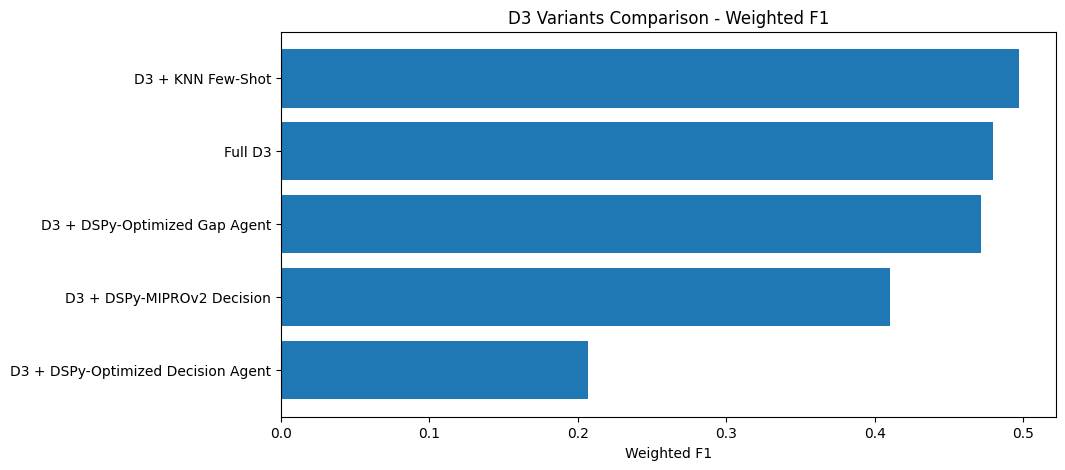

In [ ]:
plt.figure(figsize=(10, 5))

scores_df_plot = scores_df.sort_values("f1_weighted", ascending=True)

plt.barh(scores_df_plot["model"], scores_df_plot["f1_weighted"])
plt.xlabel("Weighted F1")
plt.title("D3 Variants Comparison - Weighted F1")
plt.show()

In [ ]:
import re

def diagnose_label(raw):
    obj = extract_json_object(str(raw))
    had_label = "label" in obj
    src = obj.get("label", raw)
    key = re.sub(r"\s+", " ", str(src).strip().lower().replace("_", " "))
    keys = ["clear non-reply","clear non reply","non-reply","non reply",
            "ambivalent","ambiguous","partial","unclear","clear reply"]
    matched = any(k in key for k in keys)
    return had_label, matched

for exp in experiments:
    df = exp["df"]
    if "d3_decision_raw" not in df.columns:
        print(f"{exp['name']:45s}  (no raw col)"); continue
    diag    = df["d3_decision_raw"].apply(diagnose_label)
    no_label = (~diag.apply(lambda t: t[0])).sum()   
    fellthru = (~diag.apply(lambda t: t[1])).sum()  
    n = len(df)
    print(f"{exp['name']:45s}  fallback→Ambivalent: {fellthru:4d}/{n} ({fellthru/n:4.1%})   no-label-field: {no_label}")

Full D3                                        fallback→Ambivalent:    0/100 (0.0%)   no-label-field: 0
D3 + KNN Few-Shot                              fallback→Ambivalent:    0/100 (0.0%)   no-label-field: 1
D3 + DSPy-Optimized Gap Agent                  fallback→Ambivalent:    0/100 (0.0%)   no-label-field: 1
D3 + DSPy-Optimized Decision Agent             fallback→Ambivalent:    0/100 (0.0%)   no-label-field: 0
D3 + DSPy-MIPROv2 Decision                     fallback→Ambivalent:    0/100 (0.0%)   no-label-field: 0


In [ ]:
def error_analysis(df, pred_col, true_col="clarity_label",
                   q_col="question", a_col="interview_answer",
                   labels=LABELS, n_examples=1):
    # Create a copy so the original results are not modified
    d = df.copy()

    # Mark each sample as correct/incorrect (gold vs predicted)
    d["correct"] = d[true_col] == d[pred_col]

    print("\n== Most common error pairs (true -> pred) ==")
    err = d[~d["correct"]]
    for (t, p), n in err.groupby([true_col, pred_col]).size().sort_values(ascending=False).items():
        print(f"  {t:16} -> {p:16}: {n}")

    # Answer / question length in words
    d["ans_len"] = d[a_col].astype(str).str.split().str.len()
    d["q_len"]   = d[q_col].astype(str).str.split().str.len()

    print("\n== Error rate by answer length ==")
    print((1 - d.groupby(pd.qcut(d["ans_len"], 4, duplicates="drop"), observed=True)["correct"].mean()).round(3))

    print("\n== Error rate by question length ==")
    print((1 - d.groupby(pd.qcut(d["q_len"], 4, duplicates="drop"), observed=True)["correct"].mean()).round(3))

    print("\n== Example error per class ==")
    # One example mistake per true class, for qualitative inspection
    for c in labels:
        for _, r in err[err[true_col] == c].head(n_examples).iterrows():
            print(f"\n[true={c} | pred={r[pred_col]}]")
            print("Q:", str(r[q_col])[:160])
            print("A:", str(r[a_col])[:240])

    return d


# Run the error analysis for every experiment/variant
for exp in experiments:
    print("\n" + "#"*90 + f"\n###  {exp['name']}\n" + "#"*90)
    error_analysis(exp["df"], pred_col=exp["pred_col"])


##########################################################################################
###  Full D3
##########################################################################################

== Most common error pairs (true -> pred) ==
  Clear Reply      -> Ambivalent      : 22
  Ambivalent       -> Clear Reply     : 16
  Clear Non-Reply  -> Ambivalent      : 9
  Clear Non-Reply  -> Clear Reply     : 1

== Error rate by answer length ==
ans_len
(0.999, 69.5]       0.48
(69.5, 218.5]       0.52
(218.5, 481.25]     0.44
(481.25, 1059.0]    0.48
Name: correct, dtype: float64

== Error rate by question length ==
q_len
(1.999, 7.0]    0.423
(7.0, 14.0]     0.519
(14.0, 19.0]    0.333
(19.0, 44.0]    0.652
Name: correct, dtype: float64

== Example error per class ==

[true=Clear Reply | pred=Ambivalent]
Q: Do you think that it would be easier to reopen and restart businesses if we could produce more of those machines for people?
A: We're trying to do that. That's a great question. We'r

# Best Model Selection

Across both experimental sets, the variants were compared primarily on **weighted-F1**, which accounts for the imbalanced label distribution, while **macro-F1** was also tracked to monitor performance on the minority *Clear Non-Reply* class.

Among all tested configurations, the **Full D3 pipeline with the Revised Answer Content Agent** achieved the best results, with a weighted-F1 of **0.571** and a macro-F1 of **0.491** — the highest on *both* metrics. Compared with the baseline Full D3 (0.533 weighted / 0.407 macro), this shows that constraining the Answer Content Agent — applying a stricter definition of a direct answer and routing political rhetoric into `off_target_content` — reduces the over-optimistic content extraction that previously pushed borderline answers toward *Clear Reply*.

The **D3 + kNN Few-Shot** variant (0.497 weighted / 0.413 macro) was also a strong candidate and was **not selected mainly for runtime reasons**. For every instance it builds a sentence embedding, retrieves the nearest neighbours from the training pool, and constructs a dynamic prompt, which is expensive to run over the full test set in the limited Kaggle environment. Moreover, the kNN result was measured on a different (smaller) validation split than the manual variants, so the two scores are not directly comparable. Given its dynamic, instance-specific demonstrations, kNN could plausibly reach a comparable or even better result than the selected configuration, especially on borderline *Clear Reply* vs *Ambivalent* cases. The final choice therefore reflects a trade-off between performance and runtime rather than a clear quality gap.

This configuration keeps the Question Intent, Gap & Evasion, and Decision Agents with their original prompts and replaces only the Answer Content Agent with its revised version. Given the relatively small validation set, the absolute scores should be read with some caution. It is selected as the final model and evaluated below on the held-out **test set** to produce the Kaggle submission.

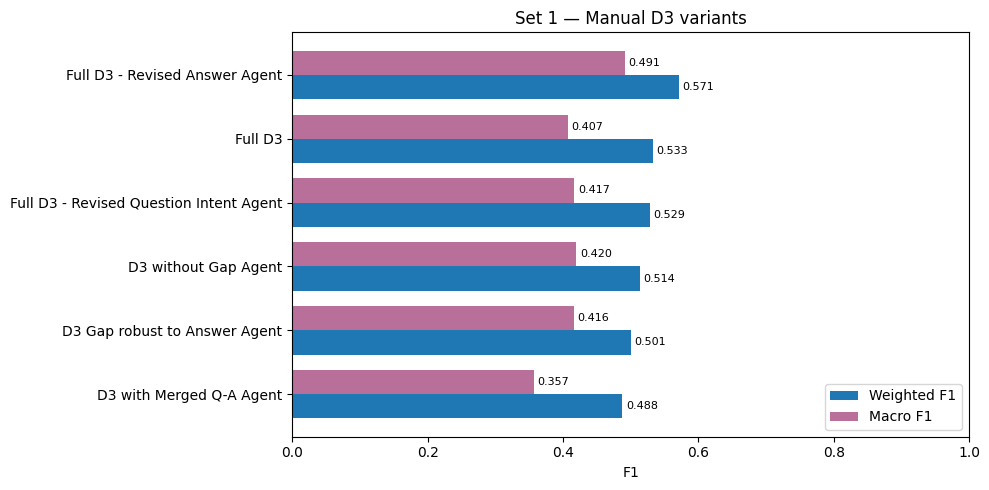

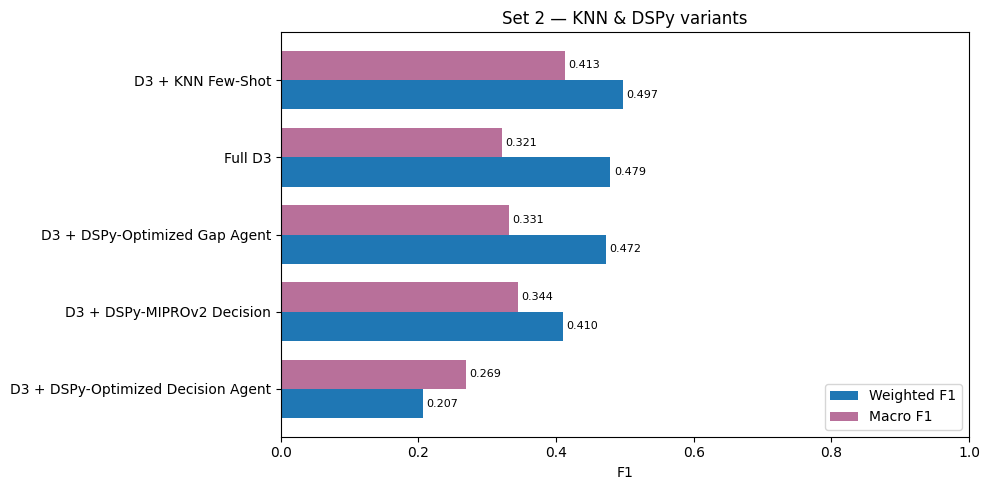

In [15]:

set1 = [  # Manual D3 variants
    ("Full D3",                                  0.533, 0.407),
    ("Full D3 - Revised Answer Agent",           0.571, 0.491),
    ("Full D3 - Revised Question Intent Agent",  0.529, 0.417),
    ("D3 without Gap Agent",                     0.514, 0.420),
    ("D3 Gap robust to Answer Agent",            0.501, 0.416),
    ("D3 with Merged Q-A Agent",                 0.488, 0.357),
]
set2 = [  # KNN & DSPy variants
    ("D3 + KNN Few-Shot",                   0.497, 0.413),
    ("Full D3",                             0.479, 0.321),
    ("D3 + DSPy-Optimized Gap Agent",       0.472, 0.331),
    ("D3 + DSPy-MIPROv2 Decision",          0.410, 0.344),
    ("D3 + DSPy-Optimized Decision Agent",  0.207, 0.269),
]

def plot_two_f1(data, title):
    data = sorted(data, key=lambda r: r[1])          # sort by weighted F1
    names = [r[0] for r in data]
    w = [r[1] for r in data]; m = [r[2] for r in data]
    y, h = np.arange(len(data)), 0.38
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(y - h/2, w, h, label="Weighted F1", color="#1f77b4")
    ax.barh(y + h/2, m, h, label="Macro F1",    color="#b8709a")
    ax.set_yticks(y); ax.set_yticklabels(names)
    ax.set_xlim(0, 1); ax.set_xlabel("F1"); ax.set_title(title)
    ax.legend(loc="lower right")
    for i,(a,b) in enumerate(zip(w, m)):
        ax.text(a+0.005, i-h/2, f"{a:.3f}", va="center", fontsize=8)
        ax.text(b+0.005, i+h/2, f"{b:.3f}", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

plot_two_f1(set1, "Set 1 — Manual D3 variants")
plot_two_f1(set2, "Set 2 — KNN & DSPy variants")

In [1]:
# d3_test = run_d3_variant_dataframe_batched(
#     df=df_test,
#     model=qwen_model,
#     tokenizer=qwen_tokenizer,
#     question_col="question",
#     answer_col="interview_answer",

#     question_intent_prompt=QUESTION_INTENT_PROMPT,
#     answer_content_prompt=ANSWER_CONTENT_PROMPT_Revised,
#     gap_evasion_prompt=GAP_EVASION_PROMPT,
#     decision_prompt=DECISION_PROMPT,

#     use_question_intent=True,
#     use_answer_content=True,
#     use_gap_evasion=True,

#     pred_col_name="pred_d3",
#     variant_name="Test",

#     limit=None,
#     batch_size=8,

#     max_tokens_question_intent=250,
#     max_tokens_answer_content=500,
#     max_tokens_gap_evasion=500,
#     max_tokens_decision=250
# )



# df_test["predicted_label"]  = d3_test["pred_d3"].apply(normalize_prediction_label)
# df_test["raw_model_output"] = d3_test["d3_decision_raw"]
# print(classification_report(df_test["clarity_label"], df_test["predicted_label"]))
# # === Submission ===
# submission = pd.DataFrame({
#     "Id": np.arange(len(df_test)),
#     "Predicted": df_test["predicted_label"].values,
# })

# valid_labels = {"Clear Reply", "Ambivalent", "Clear Non-Reply"}
# submission["Predicted"] = submission["Predicted"].where(
#     submission["Predicted"].isin(valid_labels), "Ambivalent"
# )

# submission.to_csv("/kaggle/working/submission.csv", index=False)
# print(submission["Predicted"].value_counts())
# submission.head()
